## Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import string
import warnings
from wordcloud import WordCloud
import librosa
from tqdm import tqdm
from pathlib import Path
import librosa
import re

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})
sns.set_style("whitegrid")
sns.set_palette("husl")

FIGURE_DIR = "figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

def save_fig(fig, name):
    path = os.path.join(FIGURE_DIR, f"{name}.png")
    fig.savefig(path, format='png', bbox_inches='tight')
    print(f"  -> Saved: {path}")

print("Setup completed!")

Setup completed!


## Load Data

In [3]:
df = pd.read_csv("../../data/metadata.csv", sep="|")

# Rename column speaker_name -> region
df = df.rename(columns={"speaker_name": "region"})

# Map region labels
region_map = {
    "@HUE": "Mien Trung",
    "@QuangDien": "Mien Bac",
    "@speaker": "Mien Nam"
}
df["region"] = df["region"].replace(region_map)

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nRegion distribution:")
print(df['region'].value_counts())
df.head(10)

Shape: (14475, 3)

Columns: ['audio_file', 'text', 'region']

Missing values:
audio_file    0
text          0
region        0
dtype: int64

Region distribution:
region
Mien Nam      5568
Mien Trung    4637
Mien Bac      4270
Name: count, dtype: int64


,audio_file,text,region
0,wavs/2ytfp_TYGmo_0002.wav,độc đáo. Khi bước vào thì Huyết Review dù là t...,Mien Trung
1,wavs/2ytfp_TYGmo_0009.wav,cũng ít người biết đến. Đó chính là một cái kh...,Mien Trung
2,wavs/2ytfp_TYGmo_0024.wav,Nguyệt. Và đây chính là một cái cửa tam quang ...,Mien Trung
3,wavs/2ytfp_TYGmo_0030.wav,những cái câu chuyện hết sức là ly kỳ liên qua...,Mien Trung
4,wavs/2ytfp_TYGmo_0113.wav,lạnh ngược người đấy. Và như quý vị thấy thì c...,Mien Trung
5,wavs/2ytfp_TYGmo_0150.wav,cho triều đình nhưng mà cũng mang cũng được xe...,Mien Trung
6,wavs/2ytfp_TYGmo_0172.wav,gọi là thái giám. Đó thứ nhất là những cái ngư...,Mien Trung
7,wavs/2ytfp_TYGmo_0200.wav,Năng đã dùng tiền và của cải của mình để mà cú...,Mien Trung
8,wavs/2ytfp_TYGmo_0207.wav,để hầu hạ. Do đó là nếu như 13 triệu thì có th...,Mien Trung
9,wavs/2ytfp_TYGmo_0234.wav,luận ở phía phía dưới video để chúng ta biết đ...,Mien Trung


# Structural Analysis

In [4]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text'].apply(lambda x: len(str(x)))
df['char_no_space'] = df['text'].apply(lambda x: len(str(x).replace(' ', '')))

print("Summary statistics for sequence lengths:")
print("=" * 60)
for col, label in [('word_count', 'Word Count'), ('char_count', 'Character Count (with spaces)'), ('char_no_space', 'Character Count (no spaces)')]:
    print(f"\n{label}:")
    print(f"   Mean: {df[col].mean():.1f} | Median: {df[col].median():.1f}")
    print(f"   Min: {df[col].min()} | Max: {df[col].max()}")
    print(f"   Std: {df[col].std():.1f}")

Summary statistics for sequence lengths:

Word Count:
   Mean: 21.0 | Median: 19.0
   Min: 1 | Max: 387
   Std: 11.5

Character Count (with spaces):
   Mean: 91.0 | Median: 78.0
   Min: 1 | Max: 1723
   Std: 52.3

Character Count (no spaces):
   Mean: 71.0 | Median: 60.0
   Min: 1 | Max: 1337
   Std: 40.9


In [5]:
print("Word Count Statistics by Region:")
print("=" * 70)
stats_by_region = df.groupby('region')[['word_count', 'char_count']].describe()
display(stats_by_region)

Word Count Statistics by Region:


word_count                                                       \
                count       mean        std   min   25%   50%   75%    max   
region                                                                       
Mien Bac       4270.0  26.398361  18.606083   1.0  14.0  23.0  34.0  387.0   
Mien Nam       5568.0  20.237967   5.772025  11.0  15.0  19.0  25.0   37.0   
Mien Trung     4637.0  16.993746   3.217484   2.0  16.0  18.0  19.0   25.0   

           char_count                                                           
                count        mean        std   min   25%    50%    75%     max  
region                                                                          
Mien Bac       4270.0  118.179157  83.860560   1.0  63.0  102.0  152.0  1723.0  
Mien Nam       5568.0   87.276042  25.719252  41.0  65.0   84.0  108.0   151.0  
Mien Trung     4637.0   70.553375  12.922348   8.0  68.0   76.0   78.0    81.0

  -> Saved: figures\01_histogram_word_count.png


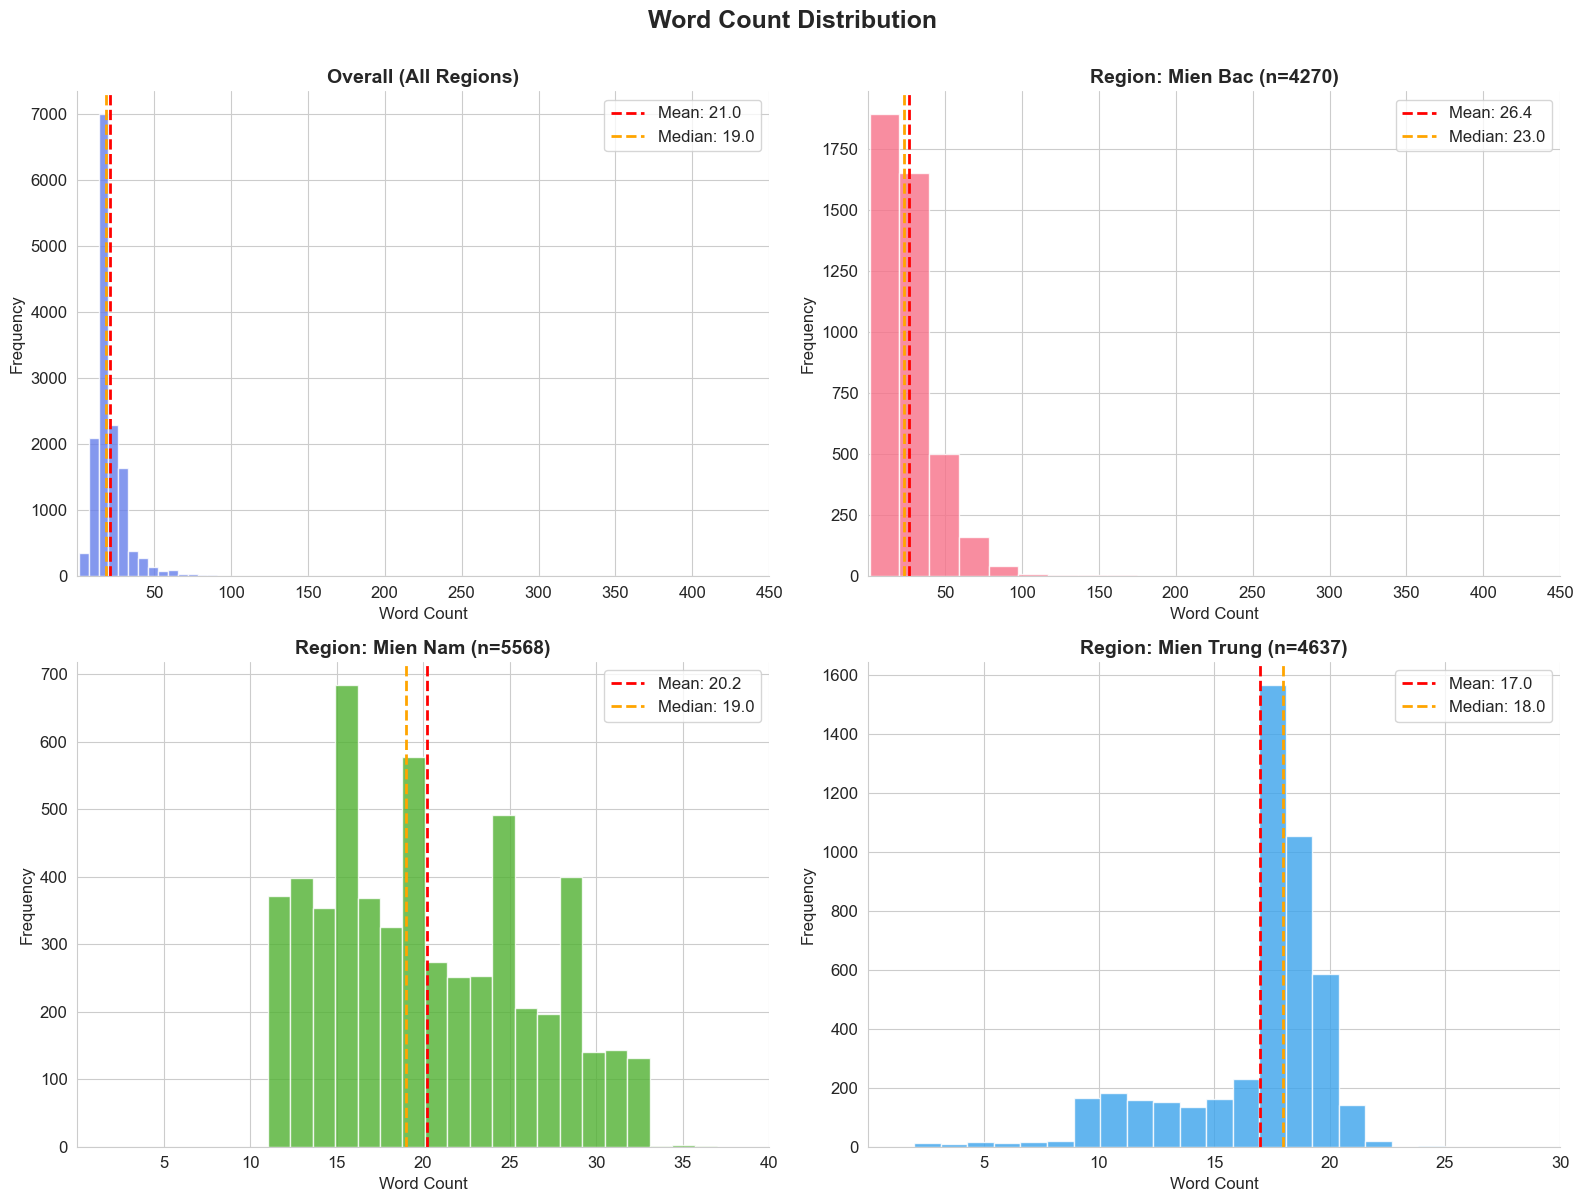

In [ ]:
# Histogram: Word Count Distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Main title
fig.suptitle('Word Count Distribution', fontsize=18, fontweight='bold', y=1)
regions = sorted(df['region'].unique())
colors = sns.color_palette("husl", n_colors=len(regions))

# Overall plot
ax = axes[0, 0]
ax.hist(df['word_count'], bins=60, color='#667eea', edgecolor='white', alpha=0.8)
ax.axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['word_count'].mean():.1f}")
ax.axvline(df['word_count'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {df['word_count'].median():.1f}")
ax.set_title('Overall (All Regions)', fontweight='bold')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()

# Region-wise plots
for i, region in enumerate(regions):
    ax = axes[(i+1)//2, (i+1)%2]
    data = df[df['region'] == region]['word_count']
    ax.hist(data, bins=20, color=colors[i], edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {data.mean():.1f}")
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {data.median():.1f}")
    ax.set_title(f'Region: {region} (n={len(data)})', fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend()

for ax in axes.flat:
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    xticks = [t for t in ax.get_xticks() if t != 0]
    ax.set_xticks(xticks)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
save_fig(fig, "01_histogram_word_count")
plt.show()

  -> Saved: figures\02_histogram_char_count.png


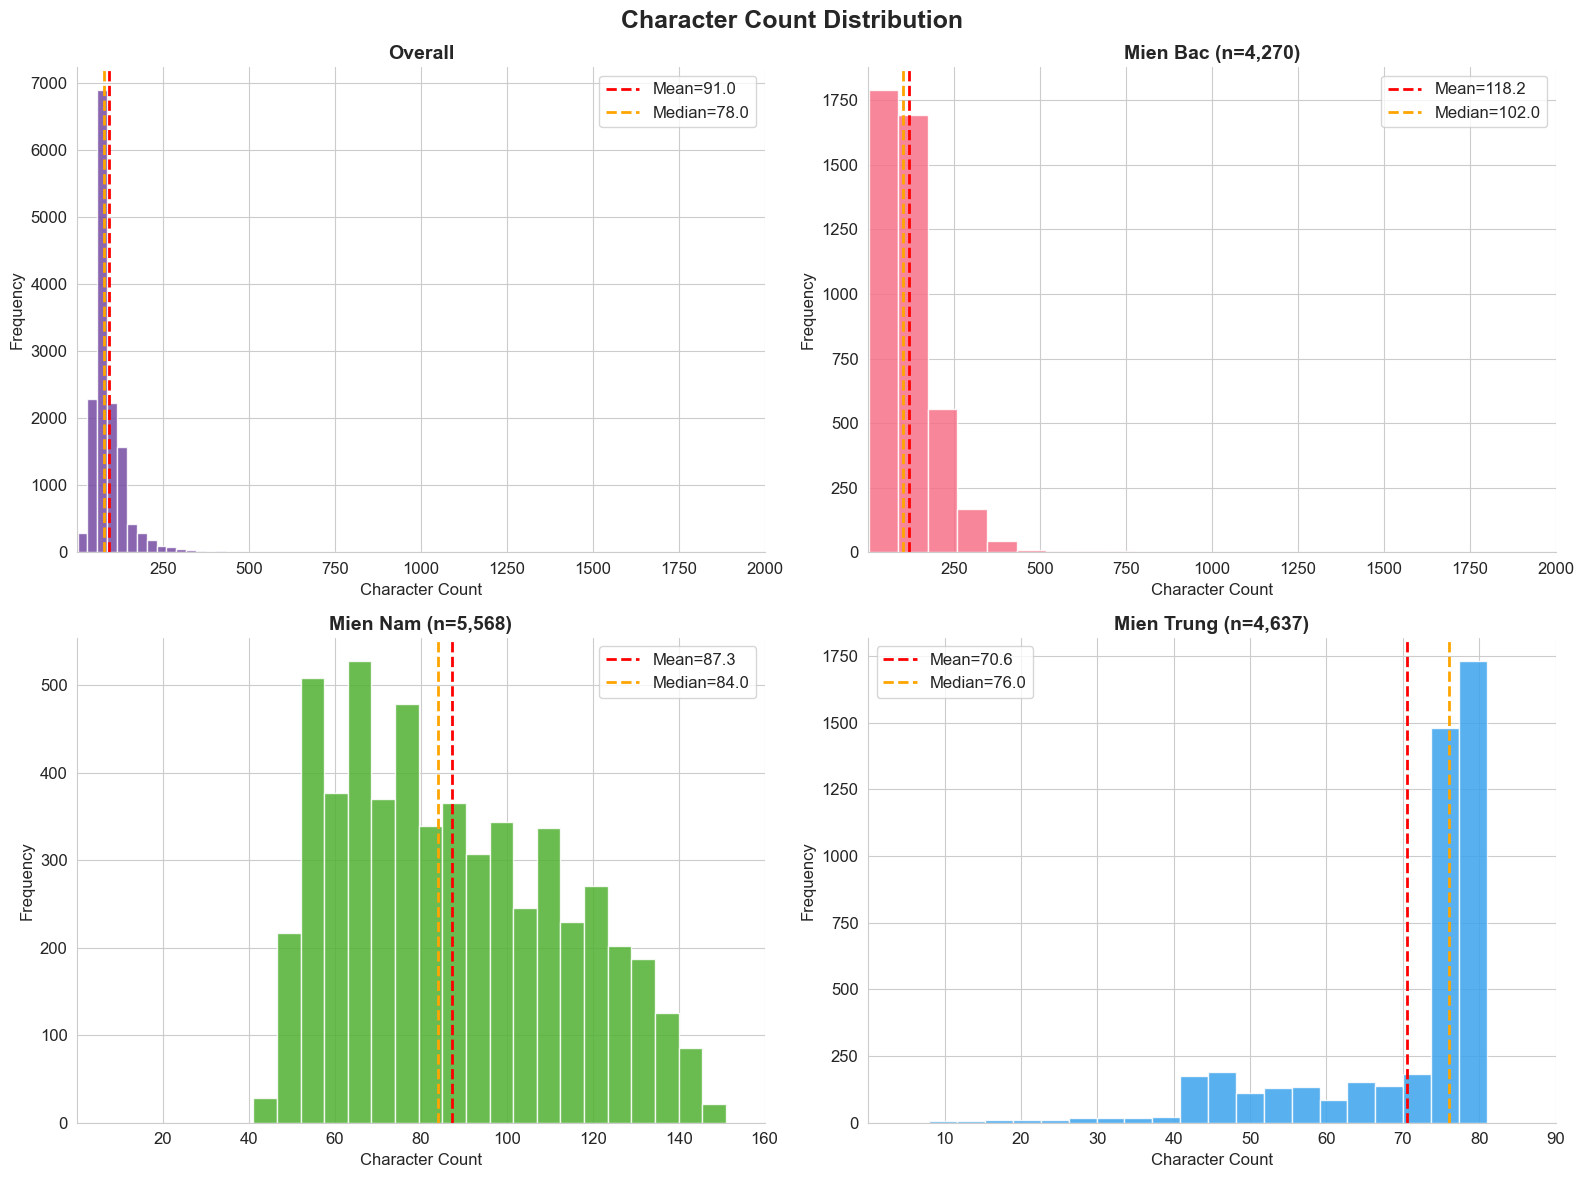

In [ ]:
# Histogram: Character Count Distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Character Count Distribution', fontsize=18, fontweight='bold')

ax = axes[0, 0]
ax.hist(df['char_count'], bins=60, color='#764ba2', edgecolor='white', alpha=0.85)
ax.axvline(df['char_count'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean={df['char_count'].mean():.1f}")
ax.axvline(df['char_count'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median={df['char_count'].median():.1f}")
ax.set_title('Overall', fontweight='bold')
ax.set_xlabel('Character Count')
ax.set_ylabel('Frequency')
ax.legend()

for i, region in enumerate(regions):
    ax = axes[(i + 1) // 2, (i + 1) % 2]
    data = df[df['region'] == region]['char_count']
    ax.hist(data, bins=20, color=colors[i], edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean={data.mean():.1f}")
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=2, label=f"Median={data.median():.1f}")
    ax.set_title(f'{region} (n={len(data):,})', fontweight='bold')
    ax.set_xlabel('Character Count')
    ax.set_ylabel('Frequency')
    ax.legend()

for ax in axes.flat:
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    xticks = [t for t in ax.get_xticks() if t != 0]
    ax.set_xticks(xticks)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
save_fig(fig, "02_histogram_char_count")
plt.show()


  -> Saved: figures\03_violin_plot_comparison.png


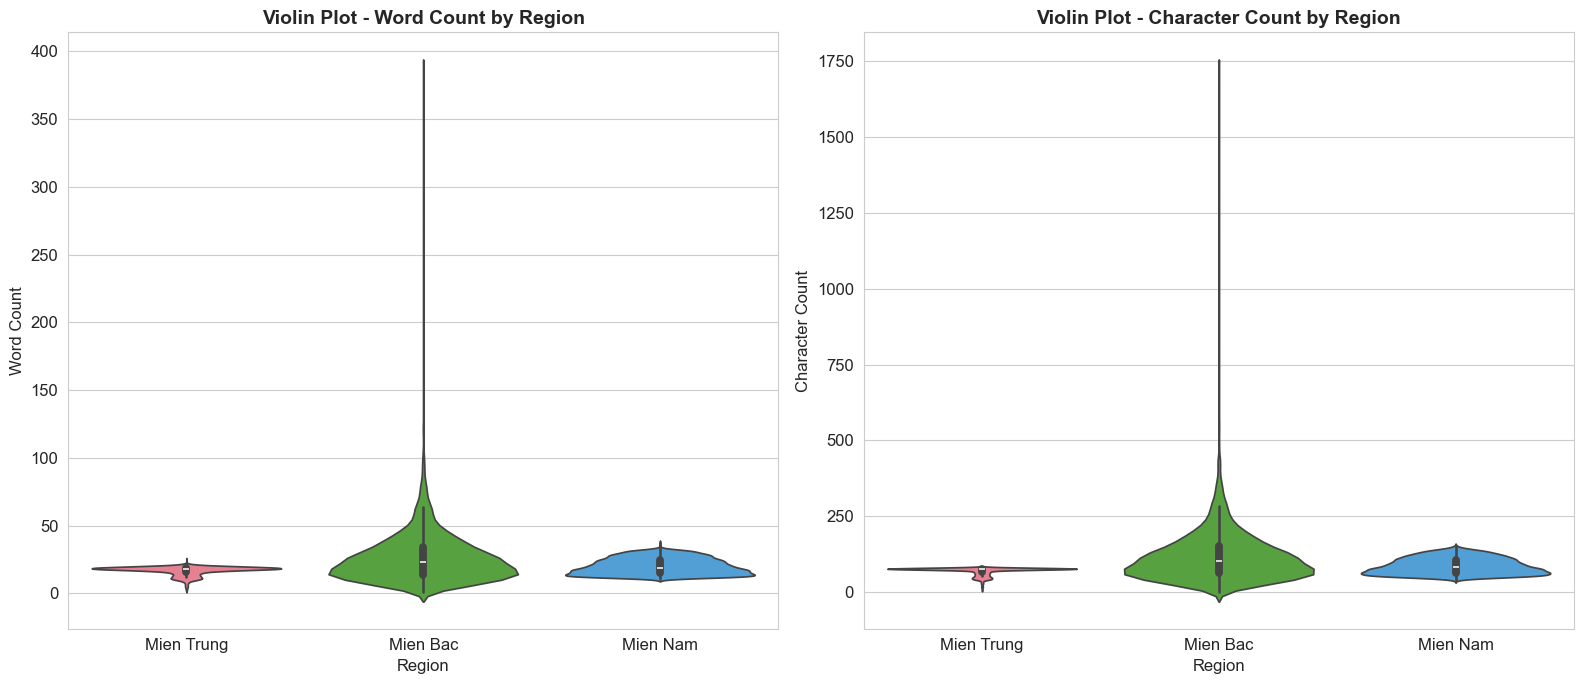

In [ ]:
# Violin Plot: Region Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.violinplot(data=df, x='region', y='word_count', palette=colors, ax=axes[0], inner='box')
axes[0].set_title('Violin Plot - Word Count by Region', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Region'); axes[0].set_ylabel('Word Count')

sns.violinplot(data=df, x='region', y='char_count', palette=colors, ax=axes[1], inner='box')
axes[1].set_title('Violin Plot - Character Count by Region', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Region'); axes[1].set_ylabel('Character Count')

plt.tight_layout()
save_fig(fig, "03_violin_plot_comparison")
plt.show()

- Miền Bắc được lấy từ dataset chuẩn trên hugging face nên độ dài của câu đa dạng hơn
- Miền Nam và Miền Trung là do nhóm tự thu thập, nên độ dài của câu có phần tập trung và ít đa dạng như miền Nam. Ngoài ra, miền trung là dữ liệu được crawl từ Youtube, có chọn lọc kỹ càng, nên độ dài của 1 câu sẽ tập trung nhất.

In [ ]:
# Percentile Analysis
print("Percentile Analysis - Word Count")
print("=" * 80)
percentiles = [5, 10, 25, 20, 75, 80, 90, 95, 99]

results = {}
for region in ['ALL'] + sorted(df['region'].unique().tolist()):
    data = df['word_count'] if region == 'ALL' else df[df['region'] == region]['word_count']
    results[region] = {f'P{p}': int(np.percentile(data, p)) for p in percentiles}
    results[region]['count'] = len(data)
pct_df = pd.DataFrame(results).T
display(pct_df)

print("\n\nPercentile Analysis - Character Count")
print("=" * 80)
results2 = {}
for region in ['ALL'] + sorted(df['region'].unique().tolist()):
    data = df['char_count'] if region == 'ALL' else df[df['region'] == region]['char_count']
    results2[region] = {f'P{p}': int(np.percentile(data, p)) for p in percentiles}
    results2[region]['count'] = len(data)
pct_df2 = pd.DataFrame(results2).T
display(pct_df2)

p10 = int(np.percentile(df['word_count'], 10))
p90 = int(np.percentile(df['word_count'], 90))
in_range = ((df['word_count'] >= p10) & (df['word_count'] <= p90)).sum()
print(f"\nCentral 80% range (P10-P90): {p10} - {p90} words")
print(f"   Samples in range: {in_range:,} / {len(df):,} ({in_range/len(df)*100:.1f}%)")

Percentile Analysis - Word Count


,P5,P10,P25,P20,P75,P80,P90,P95,P99,count
ALL,10,12,15,14,24,26,31,40,65,14475
Mien Bac,7,9,14,13,34,37,47,60,85,4270
Mien Nam,12,13,15,14,25,26,29,30,32,5568
Mien Trung,10,12,16,15,19,19,20,20,21,4637




Percentile Analysis - Character Count


,P5,P10,P25,P20,P75,P80,P90,P95,P99,count
ALL,43,50,65,61,104,114,138,179,292,14475
Mien Bac,29,39,63,56,152,167,213,265,381,4270
Mien Nam,52,55,65,62,108,113,125,133,142,5568
Mien Trung,43,48,68,62,78,79,80,80,81,4637



Central 80% range (P10-P90): 12 - 31 words
   Samples in range: 11,941 / 14,475 (82.5%)


In [ ]:
# Top 20 Longest Sentences
print("TOP 20 LONGEST SENTENCES")
print("=" * 100)
top_long = df.nlargest(20, 'word_count')[['audio_file', 'text', 'region', 'word_count', 'char_count']]
for idx, row in top_long.iterrows():
    print(f"\n[{row['region']}] Words={row['word_count']}, Chars={row['char_count']}")
    print(f"  File: {row['audio_file']}")
    text_preview = row['text'][:200] + "..." if len(str(row['text'])) > 200 else row['text']
    print(f"  Text: {text_preview}")
    print("-" * 100)

TOP 20 LONGEST SENTENCES

[Mien Bac] Words=387, Chars=1723
  File: wavs/11_0100_s100.wav
  Text: Giặc Pháp biết rõ từ lâu sự quan trọng về mặt chiến lược của sông Cửu Long mà trước kia chúng đã thử thám hiểm để tìm đường qua miền Nam Trung Hoa. Sông Cửu Long tuy có nhiều thác hiểm trở, nhưng con ...
----------------------------------------------------------------------------------------------------

[Mien Bac] Words=280, Chars=1253
  File: wavs/02_0010_s10.wav
  Text: - Thay đổi nghề nhanh chóng, nguồn lợi thiên nhiên dồi dào như bắt cá đồng, cá biển, ăn ong mật, sáp, đốn củi, nghề câu sấu, làm thầy trị rắn vẫn sống khỏe và thâu lợi nhanh hơn làm ruộng. Nhờ dự trữ ...
----------------------------------------------------------------------------------------------------

[Mien Bac] Words=170, Chars=753
  File: wavs/04_0077_s77.wav
  Text: - chữ của ông bà để lại, nhắc nhở đạo lý “Anh về học lấy chữ nhu, chín thu em đợi, mười thu em chờ”, mặc dầu giặc Pháp đang thắng thế, “đèn Sài Gòn ngọn

- 20 câu dài nhất đều xuất phát từ dataset miền Bắc đúng như phân tích ở trên, và số lượng từ và ký tự cao hơn rất nhiều so với giá trị trung bình, do đó đây chính là các outlier

In [ ]:
# Top 20 Shortest Sentences
print("TOP 20 SHORTEST SENTENCES")
print("=" * 100)
top_short = df.nsmallest(20, 'word_count')[['audio_file', 'text', 'region', 'word_count', 'char_count']]
for idx, row in top_short.iterrows():
    print(f"[{row['region']}] Words={row['word_count']}, Chars={row['char_count']}")
    print(f"  File: {row['audio_file']}")
    print(f"  Text: {row['text']}")
    print("-" * 60)

TOP 20 SHORTEST SENTENCES
[Mien Bac] Words=1, Chars=4
  File: wavs/10_0087_s87.wav
  Text: Đốc.
------------------------------------------------------------
[Mien Bac] Words=1, Chars=4
  File: wavs/10_0014_s14.wav
  Text: S.N.
------------------------------------------------------------
[Mien Bac] Words=1, Chars=1
  File: wavs/11_0043_s43.wav
  Text: Ở
------------------------------------------------------------
[Mien Bac] Words=1, Chars=3
  File: wavs/10_0079_s79.wav
  Text: An.
------------------------------------------------------------
[Mien Bac] Words=1, Chars=5
  File: wavs/13_0145_s145.wav
  Text: Ngãi.
------------------------------------------------------------
[Mien Bac] Words=1, Chars=5
  File: wavs/09_0020_s20.wav
  Text: 1930.
------------------------------------------------------------
[Mien Bac] Words=1, Chars=7
  File: wavs/09_0078_s78.wav
  Text: Nguyễn.
------------------------------------------------------------
[Mien Bac] Words=1, Chars=1
  File: wavs/12_0031_s31.wa

- Điều bất ngờ là các câu ngắn (1-2 từ) đa phần nằm ở giọng miền Bắc, cho thấy đúng là dataset của miền Bắc có sự đa dạng hơn về độ dài câu. 

# Linguistic & Vocabulary Analysis

  -> Saved: figures\04_top20_word_frequency.png


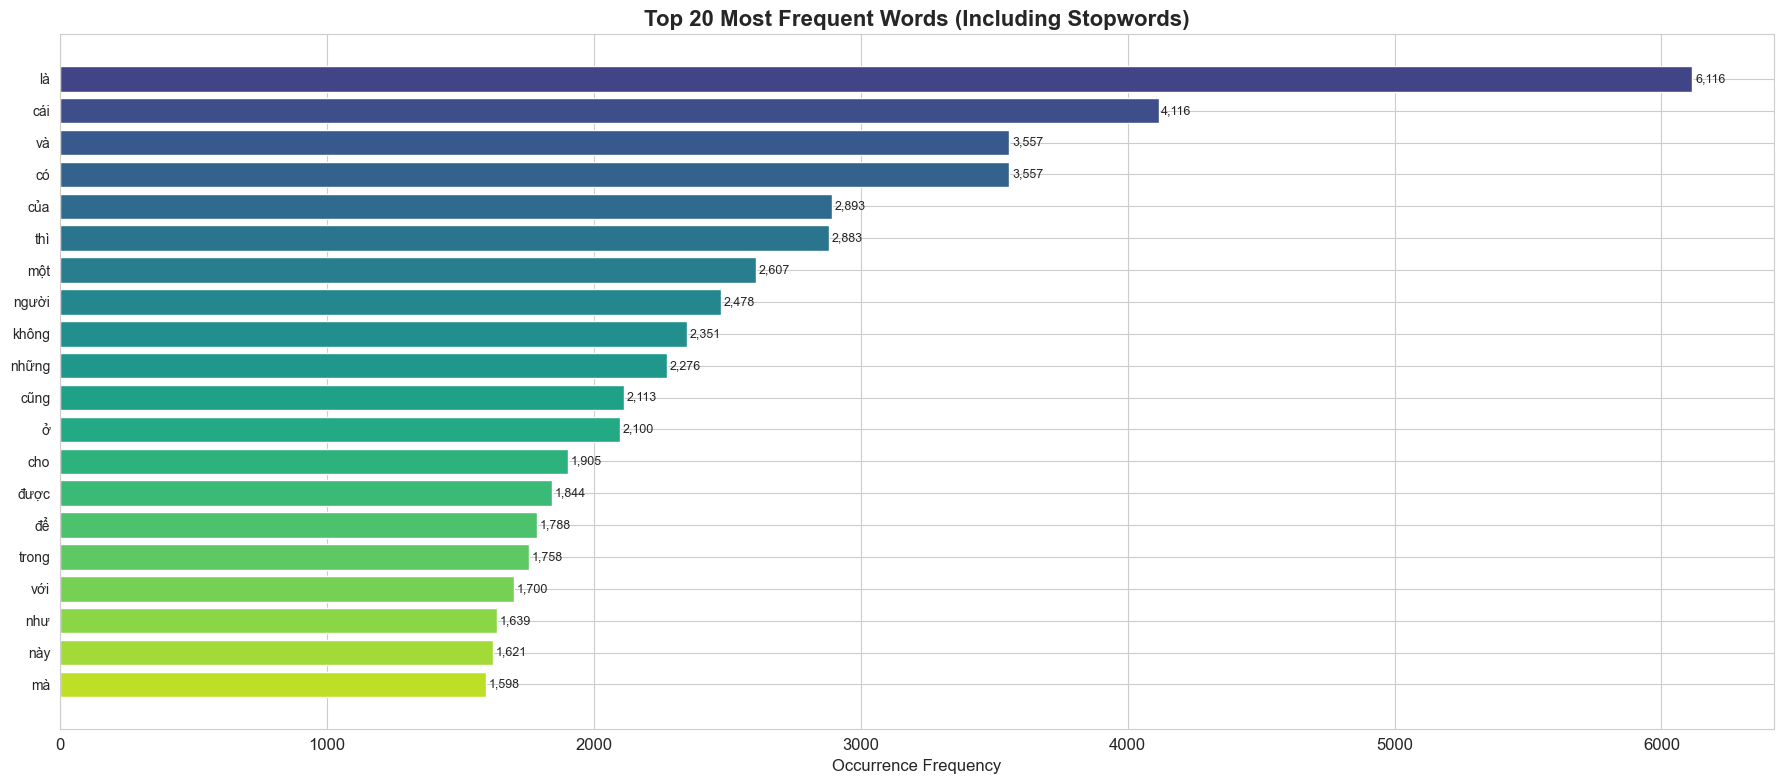

  -> Saved: figures\05_top20_word_freq_no_stopwords.png


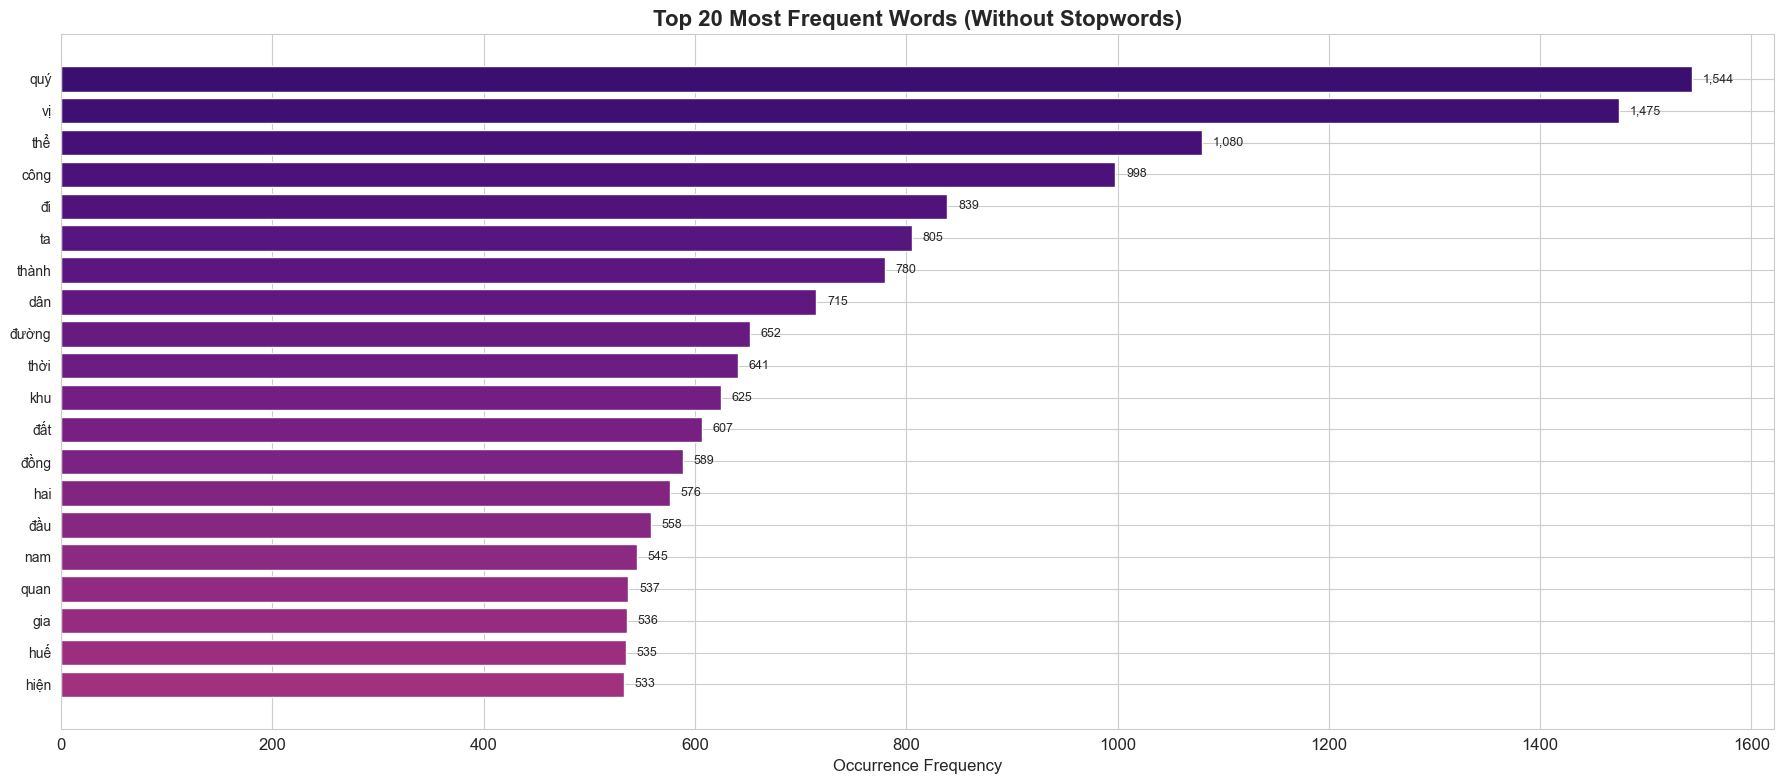

In [ ]:
# Vocabulary Frequency Analysis - Top 20
with open('../../data/vietnamese-stopwords.txt', encoding='utf-8') as f:
    vn_stopwords = set(line.strip() for line in f if line.strip())

all_words = []
for text in df['text']:
    words = str(text).lower().split()
    all_words.extend(words)

word_freq = Counter(all_words)
top20 = word_freq.most_common(20)

fig, ax = plt.subplots(figsize=(18, 8))
words_list = [w for w, c in top20]
counts_list = [c for w, c in top20]
bars = ax.barh(range(len(top20)-1, -1, -1), counts_list, color=plt.cm.viridis(np.linspace(0.2, 0.9, 20)))
ax.set_yticks(range(len(top20)-1, -1, -1))
ax.set_yticklabels(words_list, fontsize=10)
ax.set_xlabel('Occurrence Frequency', fontsize=12)
ax.set_title('Top 20 Most Frequent Words (Including Stopwords)', fontsize=16, fontweight='bold')
for i, (bar, count) in enumerate(zip(bars, counts_list)):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, f'{count:,}', va='center', fontsize=9)
plt.tight_layout()
save_fig(fig, "04_top20_word_frequency")
plt.show()

# Top 20 without stopwords
all_words_no_sw = [w for w in all_words if w not in vn_stopwords]
word_freq_no_sw = Counter(all_words_no_sw)
top20_ns = word_freq_no_sw.most_common(20)

fig, ax = plt.subplots(figsize=(18, 8))
words_ns = [w for w, c in top20_ns]
counts_ns = [c for w, c in top20_ns]
bars = ax.barh(range(len(top20_ns)-1, -1, -1), counts_ns, color=plt.cm.magma(np.linspace(0.2, 0.85, 50)))
ax.set_yticks(range(len(top20_ns)-1, -1, -1))
ax.set_yticklabels(words_ns, fontsize=10)
ax.set_xlabel('Occurrence Frequency', fontsize=12)
ax.set_title('Top 20 Most Frequent Words (Without Stopwords)', fontsize=16, fontweight='bold')
for i, (bar, count) in enumerate(zip(bars, counts_ns)):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, f'{count:,}', va='center', fontsize=9)
plt.tight_layout()
save_fig(fig, "05_top20_word_freq_no_stopwords")
plt.show()

  -> Saved: figures\06_wordcloud_by_region.png


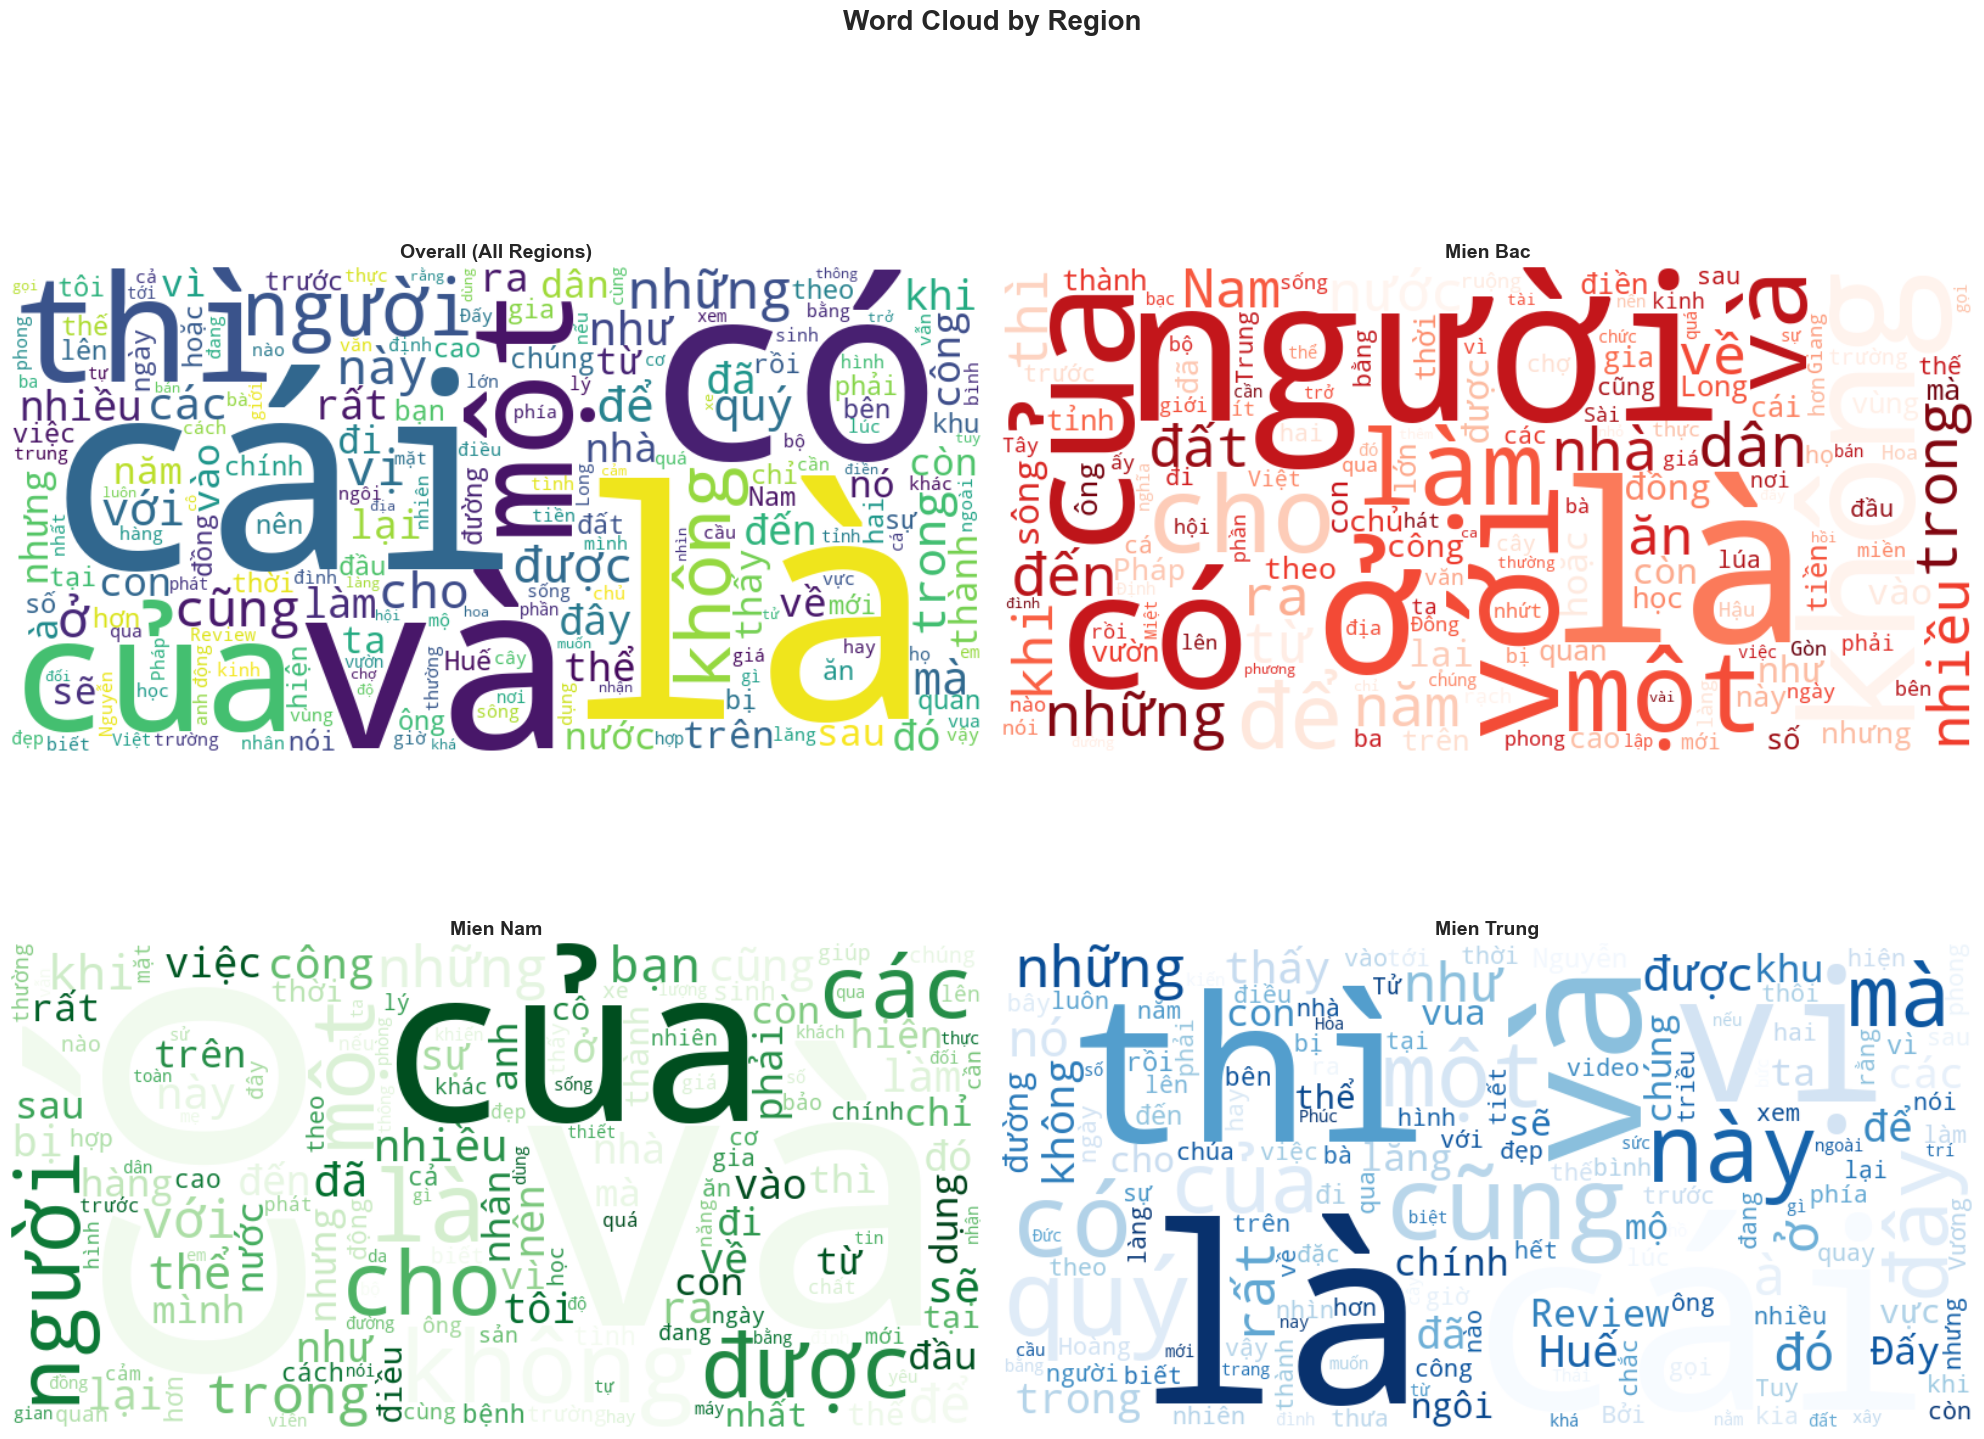

In [ ]:
# Word Cloud
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Word Cloud by Region', fontsize=20, fontweight='bold', y=1.01)

all_text = ' '.join(df['text'].astype(str).tolist())
wc = WordCloud(width=800, height=400, background_color='white', max_words=200,
               colormap='viridis', min_font_size=8, collocations=False)
wc.generate(all_text)
axes[0, 0].imshow(wc, interpolation='bilinear')
axes[0, 0].set_title('Overall (All Regions)', fontweight='bold', fontsize=14)
axes[0, 0].axis('off')

color_maps = ['Reds', 'Greens', 'Blues']
for i, region in enumerate(regions):
    ax = axes[(i+1)//2, (i+1)%2]
    text = ' '.join(df[df['region'] == region]['text'].astype(str).tolist())
    wc = WordCloud(width=800, height=400, background_color='white', max_words=150,
                   colormap=color_maps[i], min_font_size=8, collocations=False)
    wc.generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{region}', fontweight='bold', fontsize=14)
    ax.axis('off')

plt.tight_layout()
save_fig(fig, "06_wordcloud_by_region")
plt.show()

In [ ]:
# Special Character & Punctuation Analysis
all_text_combined = ''.join(df['text'].astype(str).tolist())
char_counter = Counter(all_text_combined)

vn_chars = set('aàáảãạăắằẳẵặâấầẩẫậbcdđeèéẻẽẹêếềểễệfghiìíỉĩịjklmnoòóỏõọôốồổỗộơớờởỡợpqrstuùúủũụưứừửữựvwxyỳýỷỹỵz')
vn_upper = set(c.upper() for c in vn_chars)

special_chars = {}
digits_count = {}
punctuation_count = {}

for char, count in char_counter.items():
    if char.isdigit():
        digits_count[char] = count
    elif char in string.punctuation or char in '\u201c\u201d\u2018\u2019\u2026\u2013\u2014\u2022\u00b7':
        punctuation_count[char] = count
    elif char.lower() not in vn_chars and char not in vn_upper and char != ' ':
        special_chars[char] = count

print("CHARACTER ANALYSIS")
print("=" * 60)
print(f"Total characters: {len(all_text_combined):,}")
print(f"Unique characters: {len(char_counter)}")

print(f"\nDIGITS:")
for char, count in sorted(digits_count.items(), key=lambda x: -x[1]):
    print(f"   '{char}': {count:>6,} times")

print(f"\nPUNCTUATION:")
for char, count in sorted(punctuation_count.items(), key=lambda x: -x[1]):
    print(f"   '{char}': {count:>6,} times")

print(f"\nSPECIAL / UNUSUAL CHARACTERS:")
for char, count in sorted(special_chars.items(), key=lambda x: -x[1]):
    print(f"   '{char}' (U+{ord(char):04X}): {count:>6,} times")

CHARACTER ANALYSIS
Total characters: 1,317,734
Unique characters: 204

DIGITS:
   '1':    955 times
   '0':    852 times
   '9':    468 times
   '2':    445 times
   '3':    345 times
   '5':    321 times
   '8':    297 times
   '6':    255 times
   '4':    221 times
   '7':    193 times
   '²':      2 times

PUNCTUATION:
   ',': 11,183 times
   '.':  8,050 times
   '“':    944 times
   '”':    921 times
   '-':    608 times
   ':':    421 times
   ';':    180 times
   '?':    150 times
   '[':    131 times
   ']':    131 times
   '!':     60 times
   '>':     16 times
   '/':     14 times
   '’':      7 times
   '%':      7 times
   '&':      1 times

SPECIAL / UNUSUAL CHARACTERS:
   'å' (U+00E5):      5 times
   'ä' (U+00E4):      1 times


  -> Saved: figures\07_punctuation_frequency.png


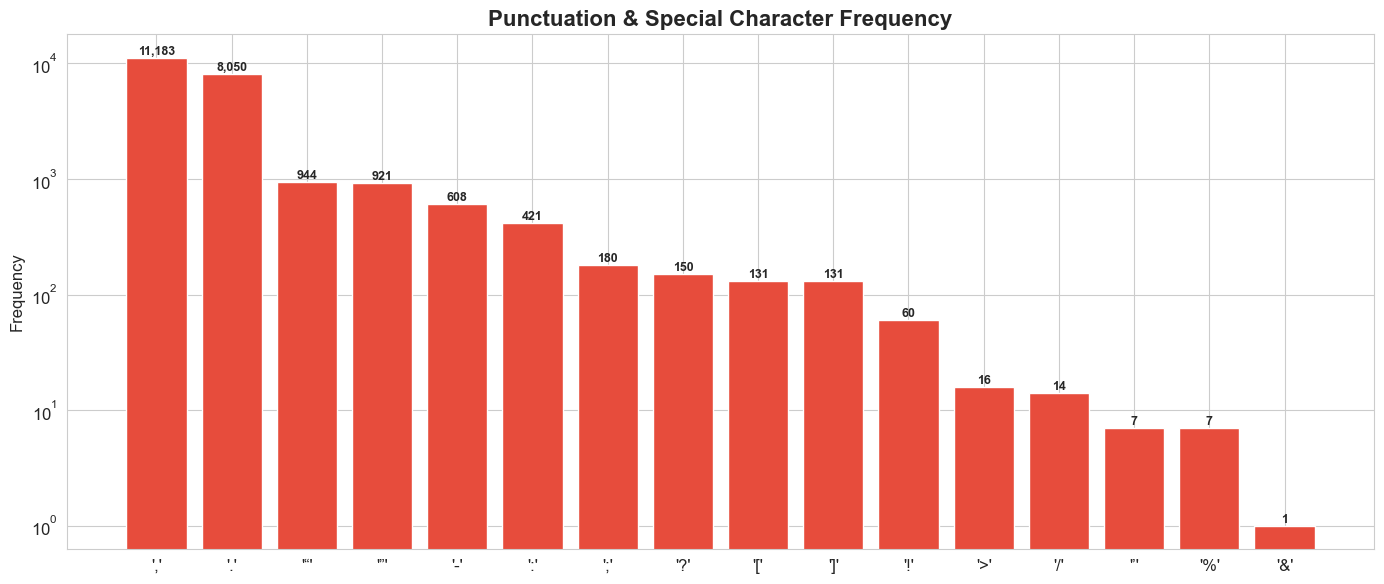

In [16]:
# Visualize punctuation frequency
punct_data = sorted(punctuation_count.items(), key=lambda x: -x[1])
if punct_data:
    fig, ax = plt.subplots(figsize=(14, 6))
    chars_p = [f"'{c}'" for c, _ in punct_data[:20]]
    counts_p = [c for _, c in punct_data[:20]]
    bars = ax.bar(range(len(chars_p)), counts_p, color='#e74c3c', edgecolor='white')
    ax.set_xticks(range(len(chars_p)))
    ax.set_xticklabels(chars_p, fontsize=12)
    ax.set_ylabel('Frequency')
    ax.set_title('Punctuation & Special Character Frequency', fontsize=16, fontweight='bold')
    ax.set_yscale('log')
    for bar, count in zip(bars, counts_p):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{count:,}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.tight_layout()
    save_fig(fig, "07_punctuation_frequency")
    plt.show()

VOCABULARY COMPARISON ACROSS REGIONS
   Mien Bac: 9,443 unique words
   Mien Nam: 3,731 unique words
   Mien Trung: 3,315 unique words

   Shared words across all regions: 1,796

EXCLUSIVE WORDS (appear in only one region):
   Mien Bac: 526 exclusive words
   Example: algérie, andré, bàu, bân, bâng, bòn, bót, bô, bôn, bường, bấn, bậu, bậy, bằm, bện, bịnh, bống, bốt, bổn, bớ
   Mien Nam: 671 exclusive words
   Example: biếu, buýt, buốt, báu, bênh, bì, bích, bít, bòng, bói, bóp, bú, búng, búp, băm, bĩ, bươu, bạnh, bấc, bấm
   Mien Trung: 198 exclusive words
   Example: bă, bĩnh, bũ, bẻo, bềa, bời, bụ, bử, bữ, bựn, chiềng, chuôi, chàu, châ, châo, chét, chấng, chều, chỗa, cuâu
  -> Saved: figures\08_vocabulary_comparison.png


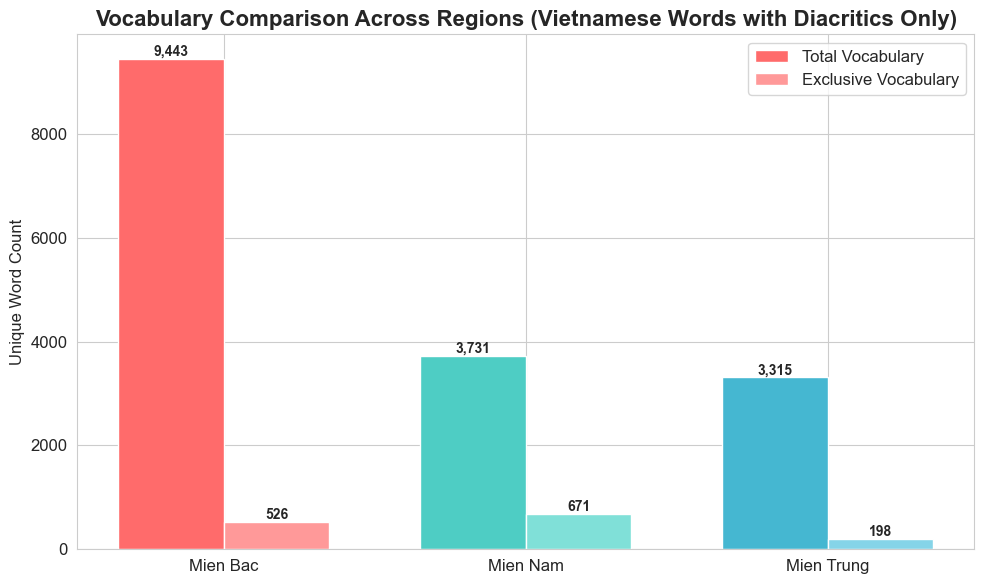

In [ ]:
# Vocabulary Comparison Across Regions
print("VOCABULARY COMPARISON ACROSS REGIONS")
print("=" * 70)

vietnamese_pattern = re.compile(
    r'[àáảãạăắằẳẵặâấầẩẫậđèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵ]'
)

vocab_by_region = {}
for region in regions:
    texts = ' '.join(df[df['region'] == region]['text'].astype(str).tolist()).lower()
    vocab_by_region[region] = set(texts.split())
    print(f"   {region}: {len(vocab_by_region[region]):,} unique words")

common_all = vocab_by_region[regions[0]]
for sp in regions[1:]:
    common_all = common_all.intersection(vocab_by_region[sp])
print(f"\n   Shared words across all regions: {len(common_all):,}")

print("\nEXCLUSIVE WORDS (appear in only one region):")
exclusive_sizes = []
exclusive_list = []
for region in regions:
    others = set()

    for sp in regions:
        if sp != region:
            others = others.union(vocab_by_region[sp])

    exclusive = vocab_by_region[region] - others

    special_chars = '\u201c\u201d\u2018\u2019\u2026\u2013\u2014\u2022\u00b7'
    exclusive = {
    word for word in exclusive
    if word.isalpha() and vietnamese_pattern.search(word)
}
    
    exclusive_sizes.append(len(exclusive))
    exclusive_list.append(exclusive)
    print(f"   {region}: {len(exclusive):,} exclusive words")
    sample = sorted(list(exclusive))[:20]
    print(f"   Example: {', '.join(sample)}")

fig, ax = plt.subplots(figsize=(10, 6))
sizes = [len(vocab_by_region[s]) for s in regions]
x = np.arange(len(regions))
width = 0.35
bar1 = ax.bar(x - width/2, sizes, width, label='Total Vocabulary', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
bar2 = ax.bar(x + width/2, exclusive_sizes, width, label='Exclusive Vocabulary', color=['#ff9999', '#80e0d8', '#85d4e8'])
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel('Unique Word Count')
ax.set_title('Vocabulary Comparison Across Regions (Vietnamese Words with Diacritics Only)', fontsize=16, fontweight='bold')
ax.legend()
for bars_group in [bar1, bar2]:
    for bar in bars_group:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
save_fig(fig, "08_vocabulary_comparison")
plt.show()

# Audio Distribution (Audio-Text Correlation)

In [ ]:
# Extract audio duration from WAV files
DATA_DIR = "../../data"
durations = []
missing_files = []

print("Extracting audio duration...")
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing"):
    wav_path = os.path.join(DATA_DIR, row['audio_file'])
    try:
        duration = librosa.get_duration(path=wav_path)
        durations.append(duration)
    except Exception as e:
        durations.append(None)
        missing_files.append((row['audio_file'], str(e)))

df['duration'] = durations
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

print(f"\nCompleted!")
print(f"   Total files: {len(df):,}")
print(f"   Success: {df['duration'].notna().sum():,}")
print(f"   Failed/Missing: {len(missing_files)}")
if missing_files:
    print(f"\nSome failed files (top 10):")
    for f_path, err in missing_files[:10]:
        print(f"   {f_path}: {err}")

Extracting audio duration...


Processing: 100%|██████████| 14475/14475 [03:57<00:00, 60.83it/s]



Completed!
   Total files: 14,475
   Success: 14,475
   Failed/Missing: 0


In [ ]:
# Audio duration statistics
df_valid = df.dropna(subset=['duration']).copy()
df_valid['words_per_min'] = df_valid['word_count'] / (df_valid['duration'] / 60)
df_valid['chars_per_sec'] = df_valid['char_count'] / df_valid['duration']

print("AUDIO DURATION STATISTICS")
print("=" * 70)
print(f"   Total duration: {df_valid['duration'].sum()/3600:.2f} hours")
print(f"   Mean: {df_valid['duration'].mean():.2f} seconds")
print(f"   Median: {df_valid['duration'].median():.2f} seconds")
print(f"   Min: {df_valid['duration'].min():.2f} sec | Max: {df_valid['duration'].max():.2f} sec")

print("\nDURATION BY REGION")
for region in regions:
    d = df_valid[df_valid['region'] == region]['duration']
    total_h = d.sum() / 3600
    print(f"   {region}: Mean={d.mean():.2f}s, Median={d.median():.2f}s, Total={total_h:.2f}h, Count={len(d)}")

AUDIO DURATION STATISTICS
   Total duration: 27.10 hours
   Mean: 6.74 seconds
   Median: 5.76 seconds
   Min: 0.03 sec | Max: 151.15 sec

DURATION BY REGION
   Mien Bac: Mean=9.16s, Median=7.67s, Total=10.86h, Count=4270
   Mien Nam: Mean=6.00s, Median=5.76s, Total=9.29h, Count=5568
   Mien Trung: Mean=5.40s, Median=5.28s, Total=6.95h, Count=4637


In [20]:
display(df_valid[df_valid['duration'] == df_valid['duration'].min()])

,audio_file,text,region,word_count,char_count,char_no_space,duration,words_per_min,chars_per_sec
6689,wavs/11_0043_s43.wav,Ở,Mien Bac,1,1,1,0.03,2000.0,33.333333


  -> Saved: figures\09_duration_distribution.png


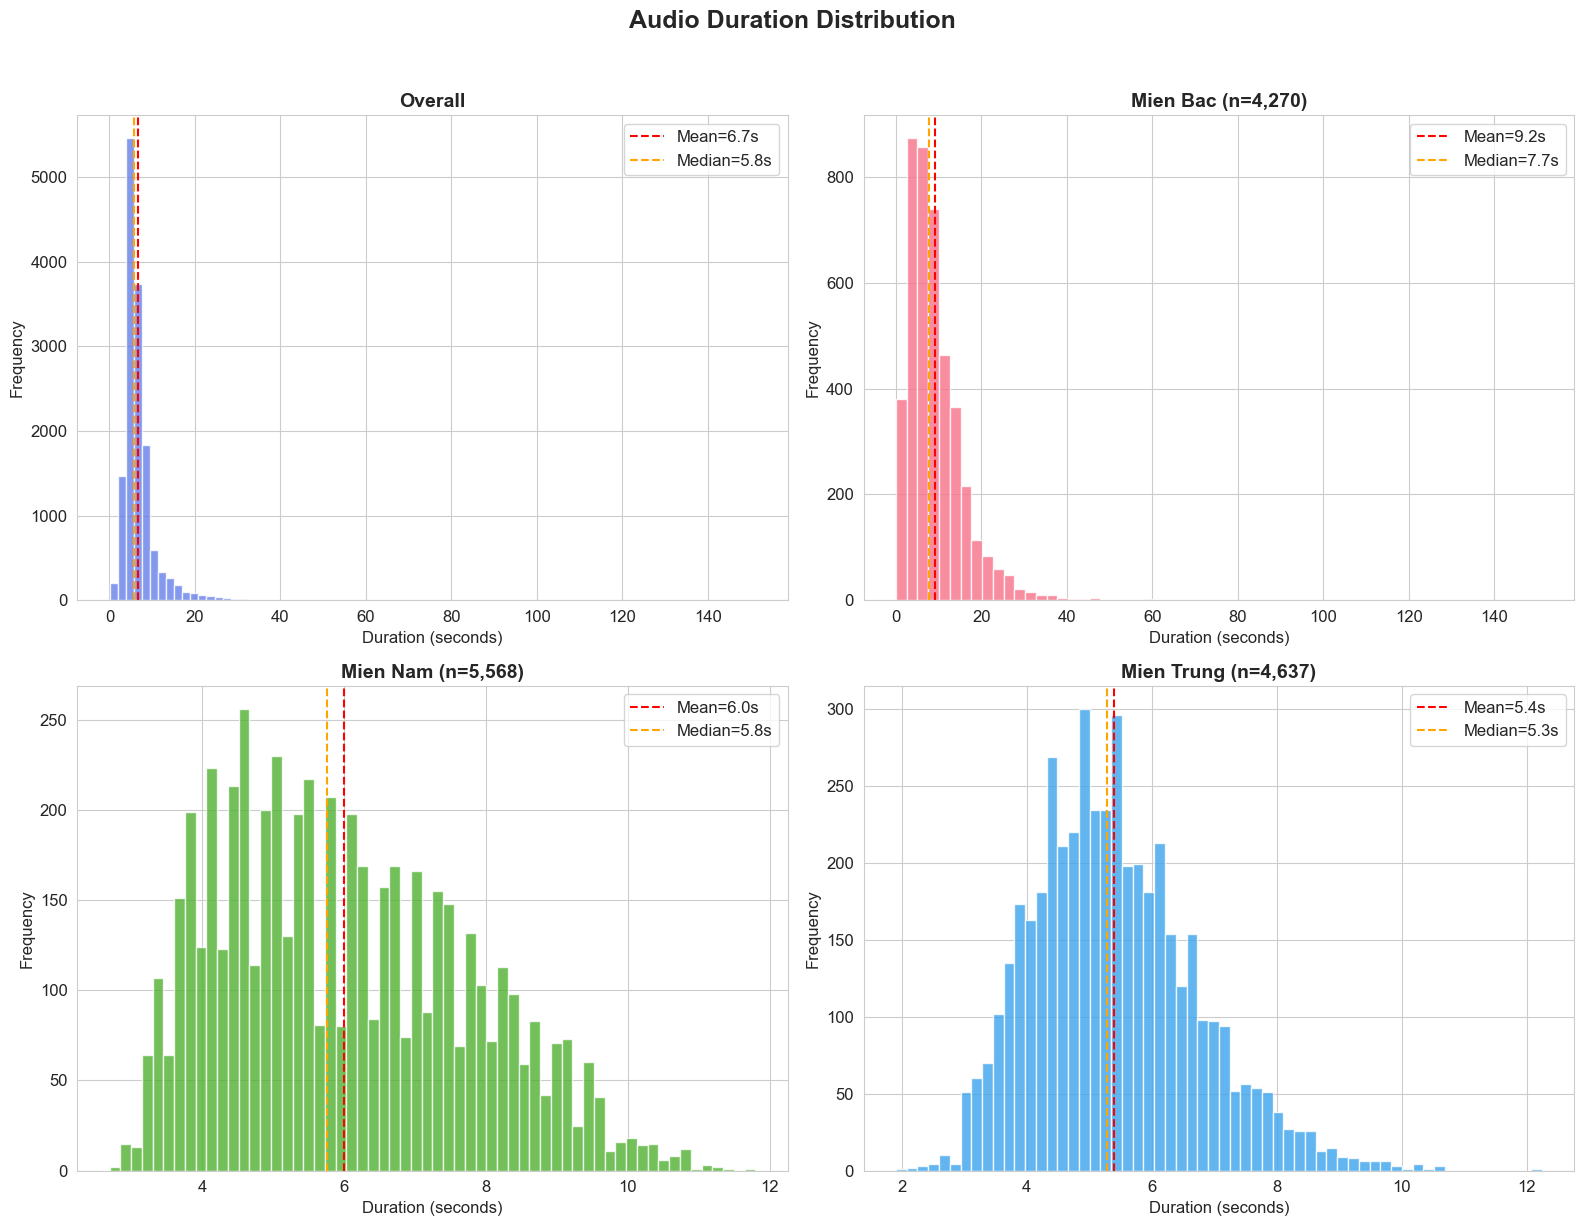

In [ ]:
# Audio Duration Distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Audio Duration Distribution', fontsize=18, fontweight='bold', y=1.02)

ax = axes[0, 0]
ax.hist(df_valid['duration'], bins=80, color='#667eea', edgecolor='white', alpha=0.8)
ax.axvline(df_valid['duration'].mean(), color='red', linestyle='--', label=f"Mean={df_valid['duration'].mean():.1f}s")
ax.axvline(df_valid['duration'].median(), color='orange', linestyle='--', label=f"Median={df_valid['duration'].median():.1f}s")
ax.set_title('Overall', fontweight='bold')
ax.set_xlabel('Duration (seconds)'); ax.set_ylabel('Frequency'); ax.legend()

for i, region in enumerate(regions):
    ax = axes[(i+1)//2, (i+1)%2]
    data = df_valid[df_valid['region'] == region]['duration']
    ax.hist(data, bins=60, color=colors[i], edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='red', linestyle='--', label=f"Mean={data.mean():.1f}s")
    ax.axvline(data.median(), color='orange', linestyle='--', label=f"Median={data.median():.1f}s")
    ax.set_title(f'{region} (n={len(data):,})', fontweight='bold')
    ax.set_xlabel('Duration (seconds)'); ax.set_ylabel('Frequency'); ax.legend()

plt.tight_layout()
save_fig(fig, "09_duration_distribution")
plt.show()

  -> Saved: figures\10_scatter_text_vs_duration.png


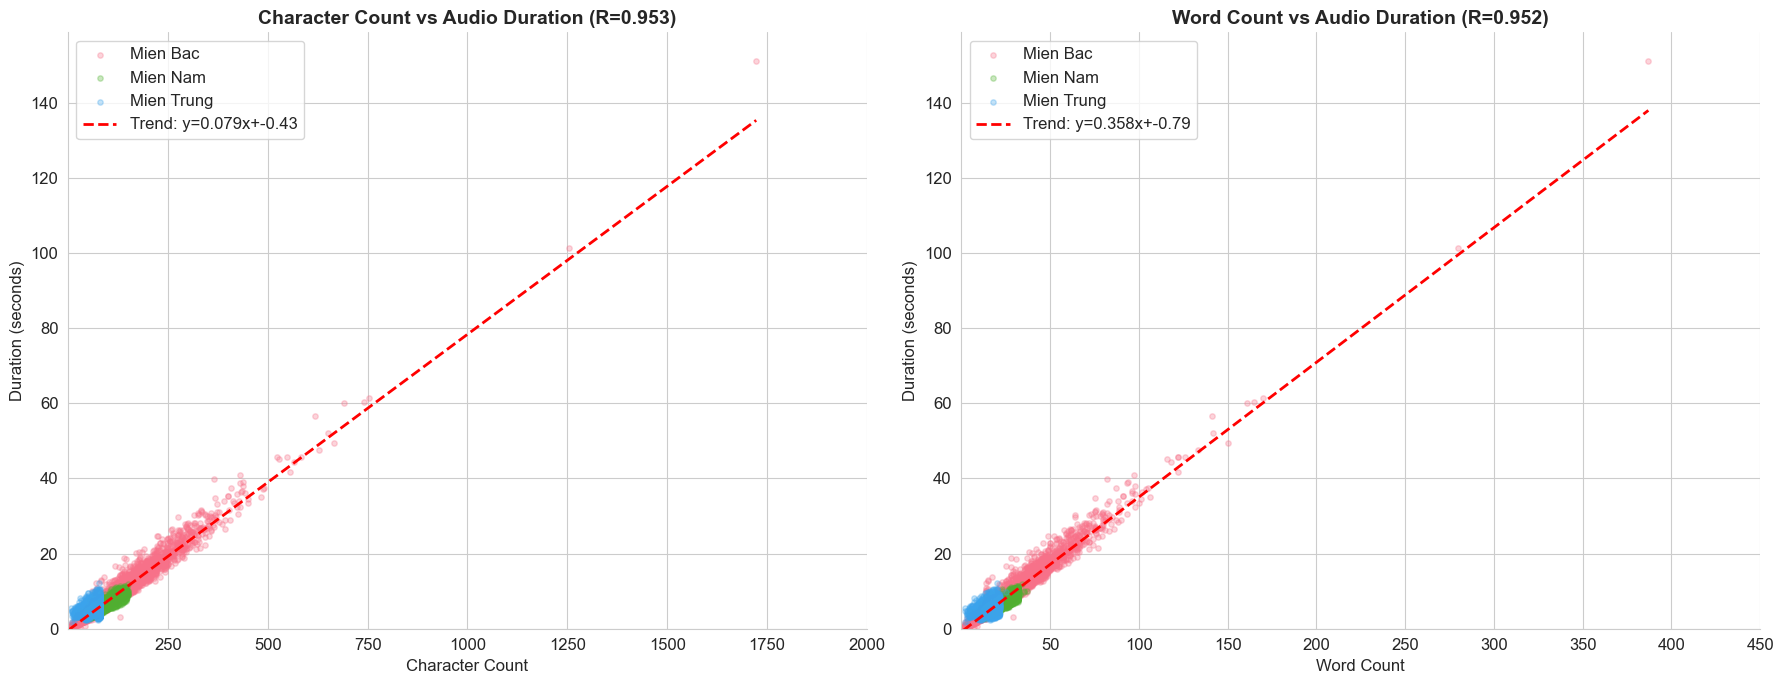

In [ ]:
# Scatter Plot: Text Length vs Duration
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
for i, region in enumerate(regions):
    d = df_valid[df_valid['region'] == region]
    ax.scatter(d['char_count'], d['duration'], alpha=0.3, s=15, label=region, color=colors[i])
z = np.polyfit(df_valid['char_count'], df_valid['duration'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_valid['char_count'].min(), df_valid['char_count'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend: y={z[0]:.3f}x+{z[1]:.2f}')
corr = df_valid['char_count'].corr(df_valid['duration'])
ax.set_title(f'Character Count vs Audio Duration (R={corr:.3f})', fontweight='bold', fontsize=14)
ax.set_xlabel('Character Count'); ax.set_ylabel('Duration (seconds)'); ax.legend()

ax = axes[1]
for i, region in enumerate(regions):
    d = df_valid[df_valid['region'] == region]
    ax.scatter(d['word_count'], d['duration'], alpha=0.3, s=15, label=region, color=colors[i])
z2 = np.polyfit(df_valid['word_count'], df_valid['duration'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df_valid['word_count'].min(), df_valid['word_count'].max(), 100)
ax.plot(x_line2, p2(x_line2), 'r--', linewidth=2, label=f'Trend: y={z2[0]:.3f}x+{z2[1]:.2f}')
corr2 = df_valid['word_count'].corr(df_valid['duration'])
ax.set_title(f'Word Count vs Audio Duration (R={corr2:.3f})', fontweight='bold', fontsize=14)
ax.set_xlabel('Word Count'); ax.set_ylabel('Duration (seconds)'); ax.legend()

for ax in axes.flat:
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    xticks = [t for t in ax.get_xticks() if t != 0]
    ax.set_xticks(xticks)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
save_fig(fig, "10_scatter_text_vs_duration")
plt.show()

SPEAKING RATE BY REGION

Mien Bac:
   Speed (words/min): Mean=183.3, Median=179.5, Std=45.0
   Speed (chars/sec): Mean=13.6, Median=13.3, Std=2.6

Mien Nam:
   Speed (words/min): Mean=203.6, Median=203.5, Std=21.5
   Speed (chars/sec): Mean=14.6, Median=14.6, Std=1.7

Mien Trung:
   Speed (words/min): Mean=198.1, Median=195.2, Std=56.0
   Speed (chars/sec): Mean=13.7, Median=13.5, Std=4.0
  -> Saved: figures\11_speaking_rate_comparison.png


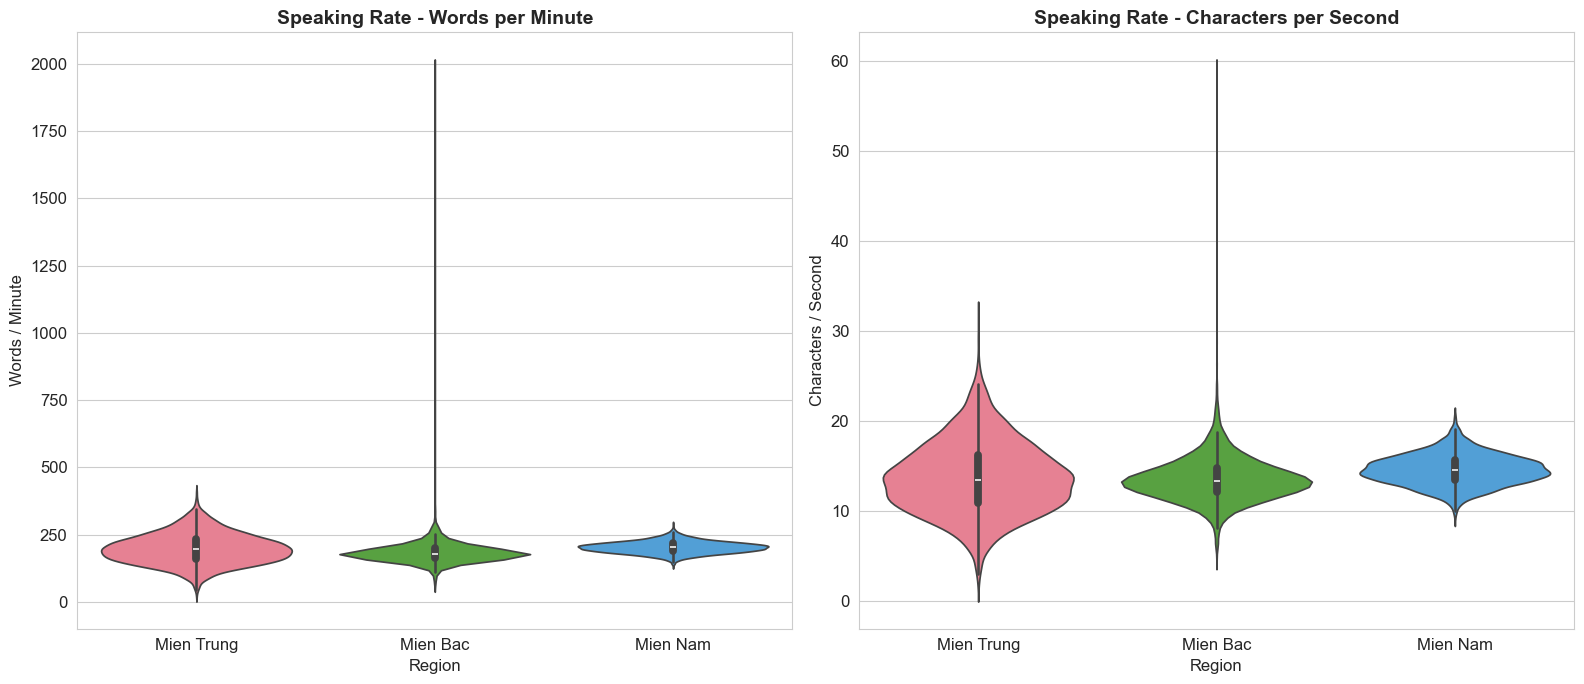

In [ ]:
# Speaking Rate Analysis
print("SPEAKING RATE BY REGION")
print("=" * 70)
for region in regions:
    d = df_valid[df_valid['region'] == region]
    wpm = d['words_per_min']
    cps = d['chars_per_sec']
    print(f"\n{region}:")
    print(f"   Speed (words/min): Mean={wpm.mean():.1f}, Median={wpm.median():.1f}, Std={wpm.std():.1f}")
    print(f"   Speed (chars/sec): Mean={cps.mean():.1f}, Median={cps.median():.1f}, Std={cps.std():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.violinplot(data=df_valid, x='region', y='words_per_min', palette=colors, ax=axes[0], inner='box')
axes[0].set_title('Speaking Rate - Words per Minute', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Words / Minute')


sns.violinplot(data=df_valid, x='region', y='chars_per_sec', palette=colors, ax=axes[1], inner='box')
axes[1].set_title('Speaking Rate - Characters per Second', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Characters / Second')


plt.tight_layout()
save_fig(fig, "11_speaking_rate_comparison")
plt.show()

In [ ]:
# Anomaly Detection
print("DETECTING ANOMALOUS DATA POINTS")
print("=" * 80)

anomalies_list = []
for region in regions:
    d = df_valid[df_valid['region'] == region].copy()
    coeffs = np.polyfit(d['char_count'], d['duration'], 1)
    d['predicted_duration'] = np.polyval(coeffs, d['char_count'])
    d['residual'] = d['duration'] - d['predicted_duration']
    d['residual_zscore'] = (d['residual'] - d['residual'].mean()) / d['residual'].std()

    anomaly_mask = d['residual_zscore'].abs() > 2.5
    anomalies = d[anomaly_mask]

    print(f"\n{region}: {len(anomalies)} anomalies (|z| > 2.5)")

    long_audio = anomalies[anomalies['residual_zscore'] > 2.5].nlargest(5, 'residual_zscore')
    if len(long_audio) > 0:
        print(f"   Short text / Long audio (possible long pauses):")
        for _, row in long_audio.iterrows():
            print(f"      {row['audio_file']}: {row['word_count']} words, {row['duration']:.1f}s (expected {row['predicted_duration']:.1f}s)")

    short_audio = anomalies[anomalies['residual_zscore'] < -2.5].nsmallest(5, 'residual_zscore')
    if len(short_audio) > 0:
        print(f"   Long text / Short audio (possible fast reading or cut):")
        for _, row in short_audio.iterrows():
            print(f"      {row['audio_file']}: {row['word_count']} words, {row['duration']:.1f}s (expected {row['predicted_duration']:.1f}s)")

    anomalies_list.append(anomalies)

total_anomalies = sum(len(a) for a in anomalies_list)
print(f"\nTOTAL: {total_anomalies} anomalies / {len(df_valid):,} samples ({total_anomalies/len(df_valid)*100:.2f}%)")

DETECTING ANOMALOUS DATA POINTS

Mien Bac: 118 anomalies (|z| > 2.5)
   Short text / Long audio (possible long pauses):
      wavs/11_0100_s100.wav: 387 words, 151.2s (expected 140.7s)
      wavs/12_0210_s210.wav: 82 words, 39.9s (expected 29.5s)
      wavs/15_0041_s41.wav: 28 words, 18.9s (expected 10.9s)
      wavs/09_0141_s141.wav: 64 words, 29.8s (expected 21.9s)
      wavs/06_0287_s287.wav: 25 words, 16.6s (expected 9.1s)
   Long text / Short audio (possible fast reading or cut):
      wavs/09_0086_s86.wav: 29 words, 3.1s (expected 10.2s)
      wavs/08_0173_s173.wav: 74 words, 22.2s (expected 27.5s)
      wavs/16_0327_s327.wav: 77 words, 21.4s (expected 26.5s)
      wavs/02_0146_s146.wav: 86 words, 26.6s (expected 31.7s)
      wavs/17_0151_s151.wav: 150 words, 49.5s (expected 54.2s)

Mien Nam: 116 anomalies (|z| > 2.5)
   Short text / Long audio (possible long pauses):
      wavs/audio_06688.wav: 23 words, 10.5s (expected 7.2s)
      wavs/audio_13010.wav: 28 words, 11.0s (expected

- Sau khi kiểm tra các video được ho là quá dài/ quá ngắn so với kỳ vọng thì có nhận xét như sau:
    - Các video dài quá kỳ vọng: Do người nói muốn nhấn mạnh, là các đoạn chuyển giữa các phân đoạn nên có khoảng nghỉ, hoặc là người nói run nên nói chuyện có chút ngập ngừng dẫn đến video dài hơn
    - Các video ngắn quá kỳ vọng: Do đoạn cắt ở trong mạch nói của người kể nên có nhanh hơn bình thường, và là những nội dung không quá quan trọng nên người nói đọc lướt

  -> Saved: figures\12_anomaly_detection.png


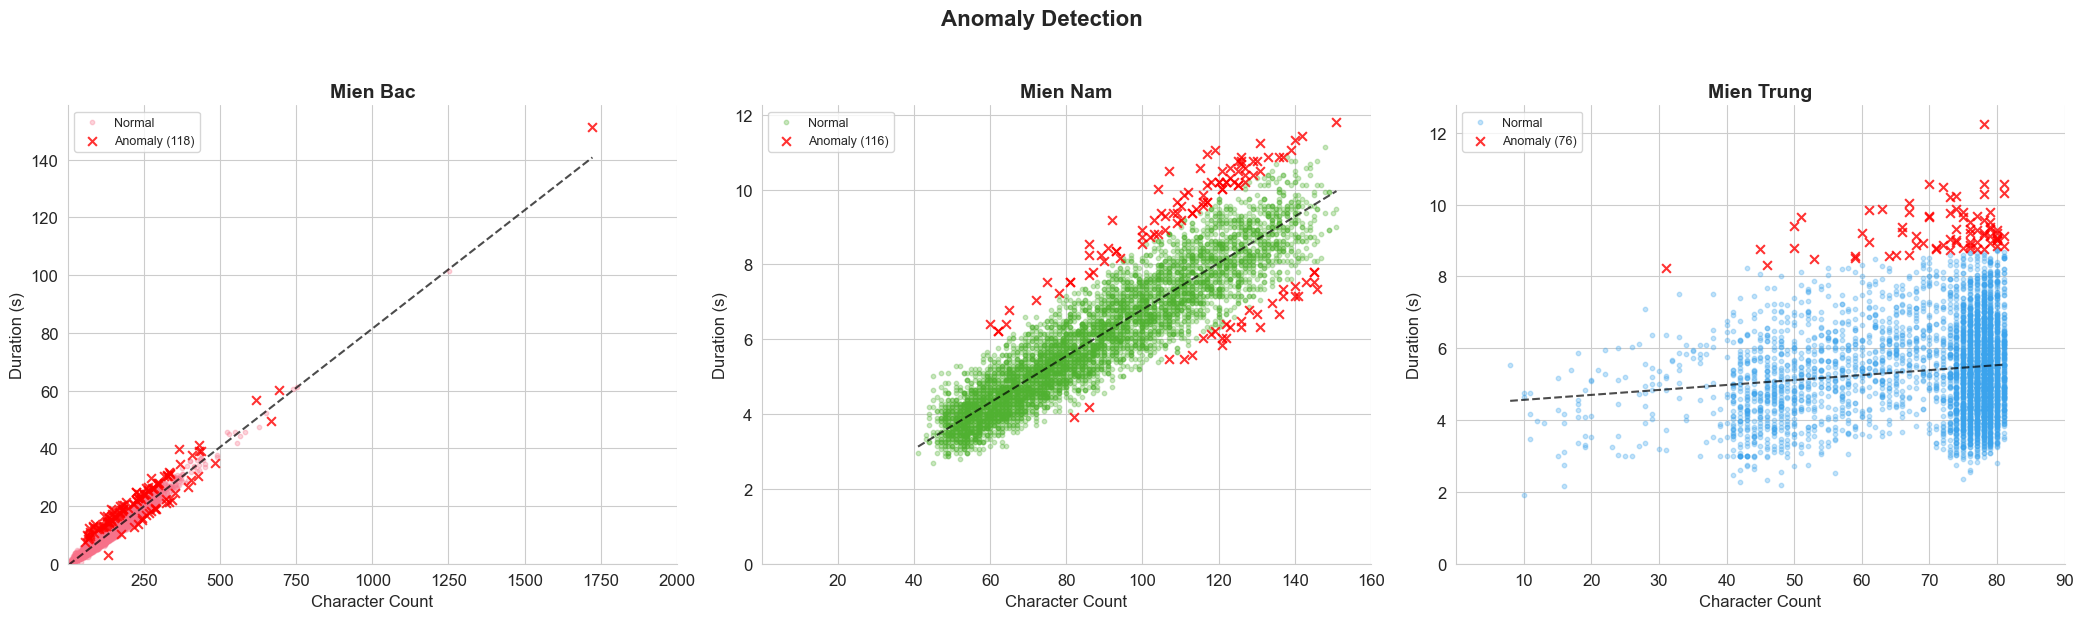

In [ ]:
# Visualize Anomalies on Scatter Plot
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Anomaly Detection', fontsize=16, fontweight='bold', y=1.03)

for idx, region in enumerate(regions):
    ax = axes[idx]
    d = df_valid[df_valid['region'] == region].copy()
    coeffs = np.polyfit(d['char_count'], d['duration'], 1)
    d['predicted_duration'] = np.polyval(coeffs, d['char_count'])
    d['residual'] = d['duration'] - d['predicted_duration']
    d['residual_zscore'] = (d['residual'] - d['residual'].mean()) / d['residual'].std()

    normal = d[d['residual_zscore'].abs() <= 2.5]
    anomaly = d[d['residual_zscore'].abs() > 2.5]

    ax.scatter(normal['char_count'], normal['duration'], alpha=0.3, s=10, color=colors[idx], label='Normal')
    ax.scatter(anomaly['char_count'], anomaly['duration'], alpha=0.8, s=40, color='red', marker='x', label=f'Anomaly ({len(anomaly)})', zorder=5)
    x_line = np.linspace(d['char_count'].min(), d['char_count'].max(), 100)
    ax.plot(x_line, np.polyval(coeffs, x_line), 'k--', linewidth=1.5, alpha=0.7)
    ax.set_title(f'{region}', fontweight='bold')
    ax.set_xlabel('Character Count'); ax.set_ylabel('Duration (s)'); ax.legend(fontsize=9)

for ax in axes.flat:
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    xticks = [t for t in ax.get_xticks() if t != 0]
    ax.set_xticks(xticks)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
save_fig(fig, "12_anomaly_detection")
plt.show()

- Ở miền Bắc là data chuẩn được lấy từ dataset chuẩn nên nhìn chung dữ liệu vẫn tập trung ở những điểm xung quanh và tập trung...
- Ở miền Nam thì dữ liệu được lấy từ sách nói do đó điểm tốc độ nói trải đều hơn...
- Ở miền Trung là dữ liệu lấy từ youtube độ trải rộng rất đều...

# Spectral Analysis

Valid files for spectral analysis: 900

Mean statistics by region:


,spectral_centroid,spectral_rolloff,zero_crossing_rate,rms_energy
region,,,,
Mien Bac,1826.7457,3521.7787,0.0671,0.1183
Mien Nam,2717.6476,5015.7489,0.0606,0.0973
Mien Trung,1425.8108,2775.6110,0.0657,0.0848


  -> Saved: figures\14_spectral_features_by_region.png


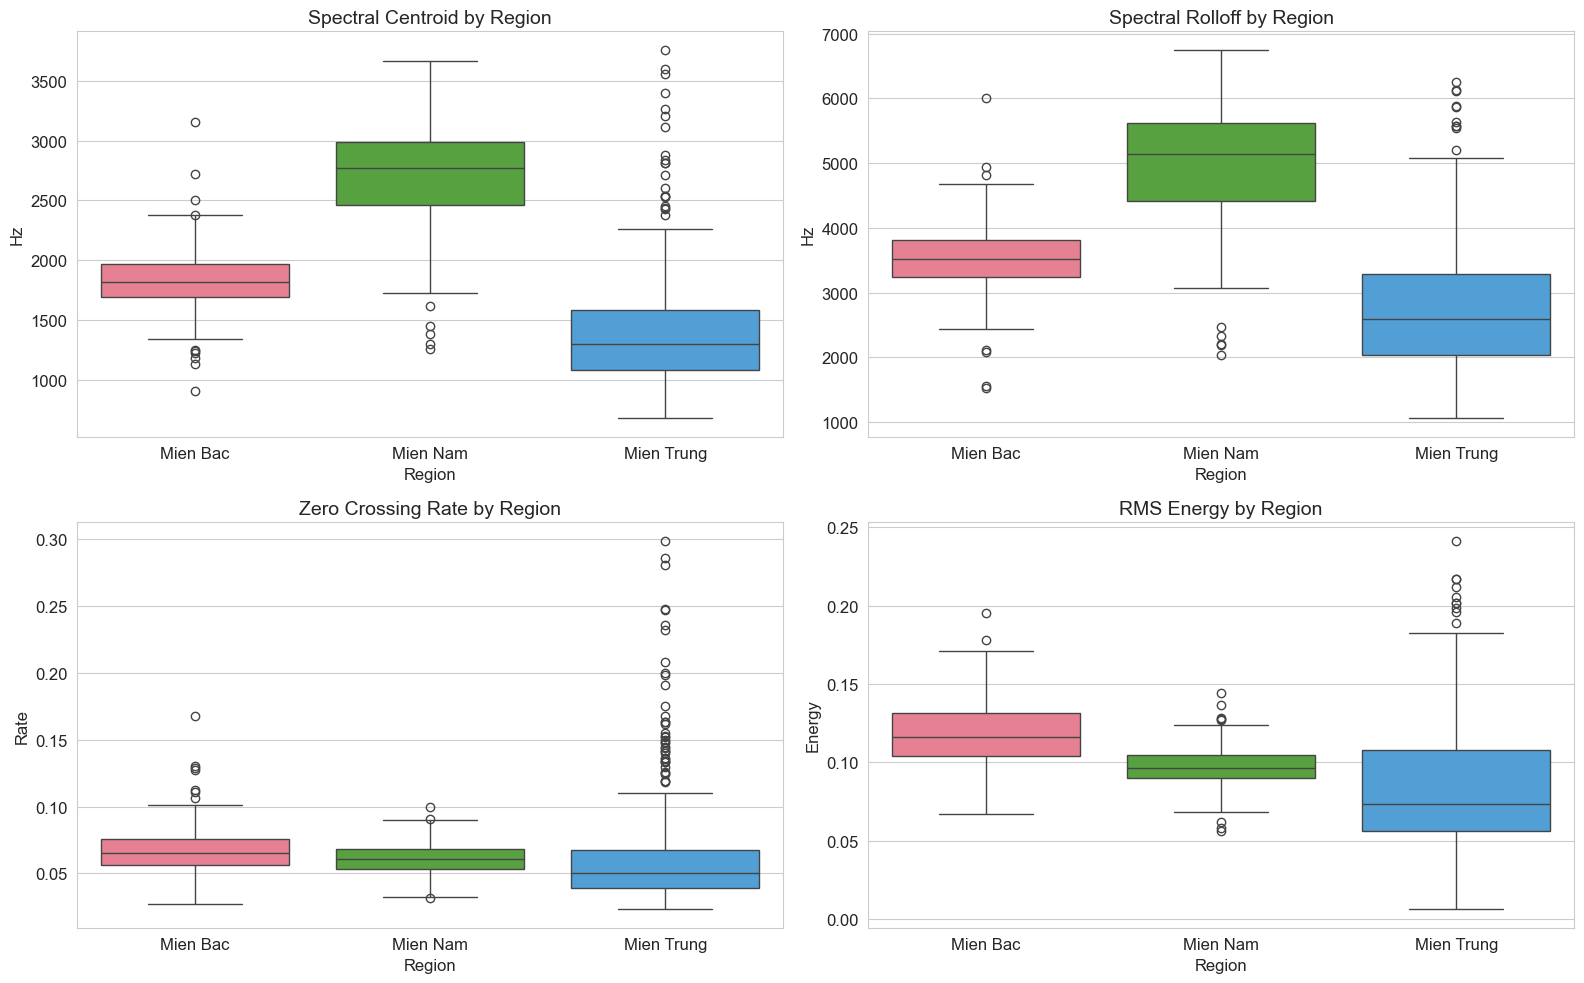

In [ ]:
# Aggregate spectral features by region
spectral_records = []
max_samples_per_region = 300

for region in sorted(df['region'].unique()):
    sub_df = df[df['region'] == region].copy()
    if len(sub_df) > max_samples_per_region:
        sub_df = sub_df.sample(max_samples_per_region, random_state=42)

    for _, row in sub_df.iterrows():
        wav_path = DATA_DIR + "/" + row['audio_file']
        if wav_path is None:
            continue
        try:
            y, sr = librosa.load(wav_path, sr=None)
            if len(y) < 512:
                continue

            spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
            spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr).mean()
            zero_crossing_rate = librosa.feature.zero_crossing_rate(y).mean()
            rms_energy = librosa.feature.rms(y=y).mean()

            spectral_records.append({
                'region': region,
                'spectral_centroid': spectral_centroid,
                'spectral_rolloff': spectral_rolloff,
                'zero_crossing_rate': zero_crossing_rate,
                'rms_energy': rms_energy
            })
        except Exception:
            continue

spectral_df = pd.DataFrame(spectral_records)
print(f'Valid files for spectral analysis: {len(spectral_df):,}')
if len(spectral_df) == 0:
    print('No valid data available for spectral analysis.')
else:
    print('\nMean statistics by region:')
    display(spectral_df.groupby('region')[['spectral_centroid', 'spectral_rolloff', 'zero_crossing_rate', 'rms_energy']].mean().round(4))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    sns.boxplot(data=spectral_df, x='region', y='spectral_centroid', ax=axes[0, 0], palette=colors)
    axes[0, 0].set_title('Spectral Centroid by Region')
    axes[0, 0].set_xlabel('Region'); axes[0, 0].set_ylabel('Hz')

    sns.boxplot(data=spectral_df, x='region', y='spectral_rolloff', ax=axes[0, 1], palette=colors)
    axes[0, 1].set_title('Spectral Rolloff by Region')
    axes[0, 1].set_xlabel('Region'); axes[0, 1].set_ylabel('Hz')

    sns.boxplot(data=spectral_df, x='region', y='zero_crossing_rate', ax=axes[1, 0], palette=colors)
    axes[1, 0].set_title('Zero Crossing Rate by Region')
    axes[1, 0].set_xlabel('Region'); axes[1, 0].set_ylabel('Rate')

    sns.boxplot(data=spectral_df, x='region', y='rms_energy', ax=axes[1, 1], palette=colors)
    axes[1, 1].set_title('RMS Energy by Region')
    axes[1, 1].set_xlabel('Region'); axes[1, 1].set_ylabel('Energy')

    plt.tight_layout()
    save_fig(fig, '14_spectral_features_by_region')
    plt.show()

  -> Saved: figures\13_mel_spectrogram_by_region.png


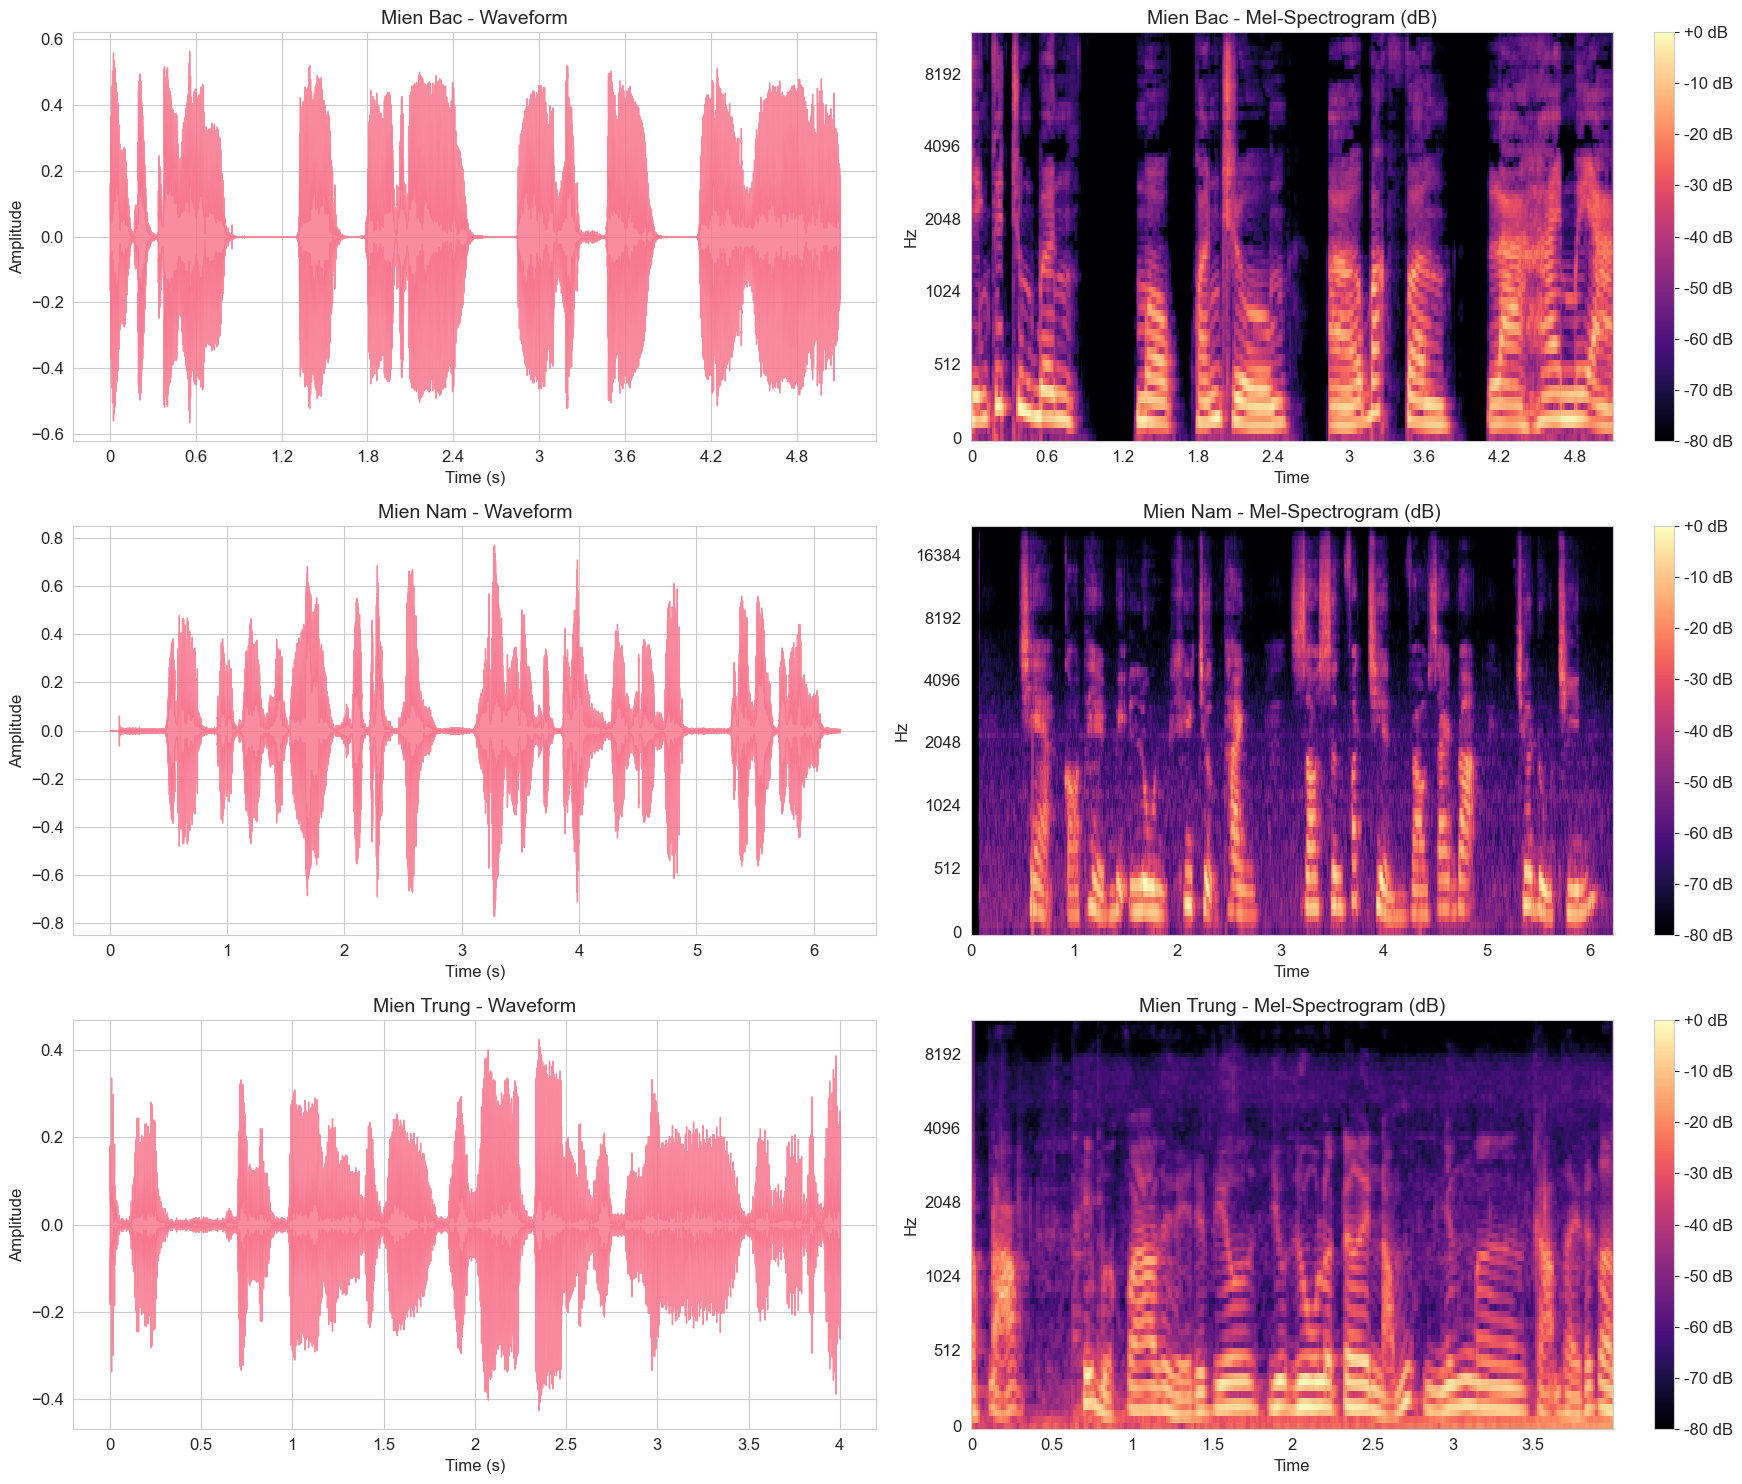

In [ ]:
# Representative mel-spectrogram by region
sample_rows = df.groupby('region', as_index=False).first()[['region', 'audio_file']]
num_regions = len(sample_rows)

fig, axes = plt.subplots(num_regions, 2, figsize=(18, 5 * num_regions))
if num_regions == 1:
    axes = np.array([axes])

for i, (_, row) in enumerate(sample_rows.iterrows()):
    region = row['region']
    wav_path = DATA_DIR + "/" + row['audio_file']

    if wav_path is None:
        axes[i, 0].text(0.5, 0.5, f'File not found\n{rel_audio}', ha='center', va='center')
        axes[i, 1].text(0.5, 0.5, f'File not found\n{rel_audio}', ha='center', va='center')
        axes[i, 0].set_title(f'{region} - Waveform')
        axes[i, 1].set_title(f'{region} - Mel-Spectrogram')
        axes[i, 0].axis('off')
        axes[i, 1].axis('off')
        continue

    y, sr = librosa.load(wav_path, sr=None)

    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0], alpha=0.8)
    axes[i, 0].set_title(f'{region} - Waveform')
    axes[i, 0].set_xlabel('Time (s)')
    axes[i, 0].set_ylabel('Amplitude')

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=256, n_mels=80)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, hop_length=256, x_axis='time', y_axis='mel', ax=axes[i, 1], cmap='magma')
    axes[i, 1].set_title(f'{region} - Mel-Spectrogram (dB)')
    fig.colorbar(img, ax=axes[i, 1], format='%+2.0f dB')

plt.tight_layout()
save_fig(fig, '13_mel_spectrogram_by_region')
plt.show()